In [78]:
# Download Packages
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import annoy

from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sc.set_figure_params(figsize=(5,5)) # no blurry figures allowed

In [79]:
# Load ATAC high-quality-rna-filtered samples
atac_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/atac_gex_filtered_pre_EA2/'

nk_sfd_atac = sc.read_h5ad(atac_dir + 'NK_SFD_atac.h5ad')
nk_hfd_atac = sc.read_h5ad(atac_dir + 'NK_HFD_atac.h5ad')
nk_glp_atac = sc.read_h5ad(atac_dir + 'NK_GLP_atac.h5ad')
nk_cr_atac  = sc.read_h5ad(atac_dir + 'NK_CR_atac.h5ad')

samples_atac = {
    'NK_SFD': nk_sfd_atac,
    'NK_HFD': nk_hfd_atac,
    'NK_GLP': nk_glp_atac,
    'NK_CR':  nk_cr_atac,
}

In [80]:
# Investigating Structure of ATAC Data
for name, adata in [('NK_SFD', nk_sfd_atac), ('NK_HFD', nk_hfd_atac), 
                    ('NK_GLP', nk_glp_atac), ('NK_CR',  nk_cr_atac)]:
    print(f"\n--- {name} ---")
    print(adata)
    print(adata.var.iloc[:3, :5].to_string())
    print("\nPeak matrix (5 cells x 5 peaks):")
    print(pd.DataFrame(
        adata.X[:5, :5].toarray(),
        index=adata.obs_names[:5],
        columns=adata.var_names[:5]
    ).to_string())
    print("\nQC metrics (5 cells):")
    print(adata.obs.iloc[:5].to_string())


--- NK_SFD ---
AnnData object with n_obs × n_vars = 4232 × 180190
    obs: 'barcode', 'sample', 'condition', 'total_insertions', 'peak_insertions', 'FRiP', 'nucleosomal_signal', 'n_counts', 'n_features_per_cell', 'tsse'
    var: 'chr', 'start', 'end', 'peak_id', 'source', 'type', 'interval'
                chr   start     end peak_id source
peak_id                                           
peak1    GL456211.1  104115  104252   peak1      .
peak2    GL456211.1  112079  112623   peak2      .
peak3    GL456211.1  112757  113177   peak3      .

Peak matrix (5 cells x 5 peaks):
peak_id                    peak1  peak2  peak3  peak4  peak5
NK_SFD:AAACAGCCACCTAAGC-1      0      0      0      0      0
NK_SFD:AAACAGCCAGATTCAT-1      0      0      0      0      0
NK_SFD:AAACATGCAAGGCCAA-1      0      0      0      0      0
NK_SFD:AAACATGCACAACAAA-1      0      0      0      0      0
NK_SFD:AAACCGAAGCTCATAA-1      0      0      0      0      0

QC metrics (5 cells):
                             

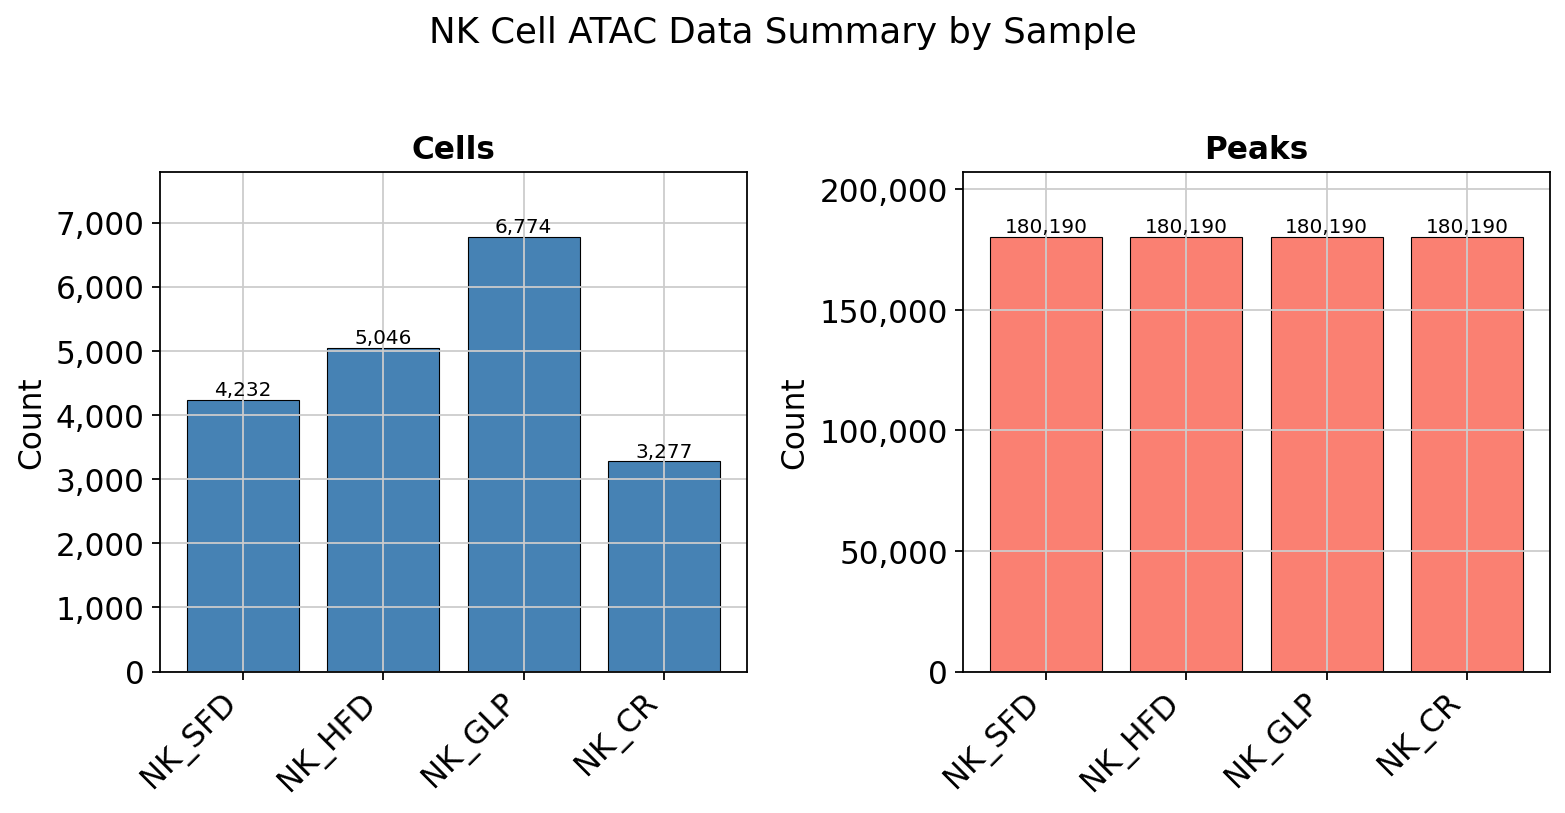

In [81]:
# Bar plot with # of cells and peaks per ATAC sample #

samples = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
atac_objects = [nk_sfd_atac, nk_hfd_atac, nk_glp_atac, nk_cr_atac]

cells = [adata.n_obs  for adata in atac_objects]
peaks = [adata.n_vars for adata in atac_objects]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

metrics = [
    ('Cells', cells, 'steelblue'),
    ('Peaks', peaks, 'salmon'),
]

for ax, (title, values, color) in zip(axes, metrics):
    ax.bar(samples, values, color=color, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(samples, rotation=45, ha='right')
    ax.set_ylim(0, max(values) * 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    for i, v in enumerate(values):
        ax.text(i, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('NK Cell ATAC Data Summary by Sample', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('atac_sample_summary_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [98]:
# ============================================================
# ATAC QC Helper Functions
# ============================================================

def atac_qc(adata, sample_name):
    """Violin plots of all ATAC QC metrics — raw overview before filtering."""
    metrics = ['total_insertions', 'n_features_per_cell', 'FRiP', 'tsse', 'nucleosomal_signal']
    labels  = ['Total Insertions', 'Features Per Cell', 'FRiP', 'TSS Enrichment', 'Nucleosomal Signal']
    ax = sc.pl.violin(adata, metrics, multi_panel=True, stripplot=False, show=False)
    for a, label in zip(ax.axes.flat, labels):
        a.set_title(label)
        a.set_xlabel(label)
    plt.suptitle(f'{sample_name} ATAC QC Metrics', fontsize=14, fontweight='bold', y=1.02)
    plt.show()


# ── Global axis limits (99.5th percentile to avoid outlier stretching) ──────
global_limits = {
    'total_insertions':    (0, max(np.percentile(adata.obs['total_insertions'], 99.5) for adata in samples_atac.values())),
    'FRiP':                (0, 1.0),
    'tsse':                (0, max(np.percentile(adata.obs['tsse'], 99.5) for adata in samples_atac.values())),
    'nucleosomal_signal':  (0, max(np.percentile(adata.obs['nucleosomal_signal'], 99.5) for adata in samples_atac.values())),
    'n_features_per_cell': (0, max(np.percentile(adata.obs['n_features_per_cell'], 99.5) for adata in samples_atac.values())),
}
print("Global axis limits:")
for k, v in global_limits.items():
    print(f"  {k}: {v}")


def atac_qc_lowqual(adata, sample_name,
                    min_insertions,
                    min_frip, min_tsse, max_nucleosomal,
                    global_limits=None):
    """
    Step 1: Flag low-quality cells.
    Thresholds: low insertions (<1000 fragments), low FRiP, low TSS, high nucleosomal signal.
    n_features_per_cell floor omitted — redundant with insertion floor, used only as doublet ceiling in Step 2.
    """
    adata.obs["low_insertions"]   = adata.obs["total_insertions"]   < min_insertions
    adata.obs["low_frip"]         = adata.obs["FRiP"]               < min_frip
    adata.obs["low_tsse"]         = adata.obs["tsse"]               < min_tsse
    adata.obs["high_nucleosomal"] = adata.obs["nucleosomal_signal"] > max_nucleosomal

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{sample_name} — Step 1: Low Quality Cell Filters', fontsize=14, fontweight='bold')

    axes[0].hist(adata.obs['total_insertions'],   bins=300, color='steelblue',   edgecolor='black', linewidth=0.3)
    axes[0].axvline(min_insertions, c='r', linestyle='--', label=f'min={min_insertions:,}\n(={min_insertions//2:,} fragments)')
    axes[0].set_title('Total Insertions'); axes[0].set_xlabel('Total Insertions'); axes[0].set_ylabel('Cell Count')
    axes[0].legend(fontsize=7)

    axes[1].hist(adata.obs['FRiP'],               bins=100, color='salmon',       edgecolor='black', linewidth=0.3)
    axes[1].axvline(min_frip, c='r', linestyle='--', label=f'min={min_frip}')
    axes[1].set_title('FRiP'); axes[1].set_xlabel('FRiP'); axes[1].set_ylabel('Cell Count')
    axes[1].legend(fontsize=7)

    axes[2].hist(adata.obs['tsse'],               bins=100, color='mediumpurple', edgecolor='black', linewidth=0.3)
    axes[2].axvline(min_tsse, c='r', linestyle='--', label=f'min={min_tsse}')
    axes[2].set_title('TSS Enrichment'); axes[2].set_xlabel('TSS Enrichment Score'); axes[2].set_ylabel('Cell Count')
    axes[2].legend(fontsize=7)

    axes[3].hist(adata.obs['nucleosomal_signal'],  bins=100, color='seagreen',    edgecolor='black', linewidth=0.3)
    axes[3].axvline(max_nucleosomal, c='r', linestyle='--', label=f'max={max_nucleosomal}')
    axes[3].set_title('Nucleosomal Signal'); axes[3].set_xlabel('Nucleosomal Signal'); axes[3].set_ylabel('Cell Count')
    axes[3].legend(fontsize=7)

    if global_limits:
        axes[0].set_xlim(global_limits['total_insertions'])
        axes[1].set_xlim(global_limits['FRiP'])
        axes[2].set_xlim(global_limits['tsse'])
        axes[3].set_xlim(global_limits['nucleosomal_signal'])

    plt.tight_layout()
    plt.show()

    print(f"  low_insertions:   {adata.obs['low_insertions'].sum():,} cells flagged")
    print(f"  low_frip:         {adata.obs['low_frip'].sum():,} cells flagged")
    print(f"  low_tsse:         {adata.obs['low_tsse'].sum():,} cells flagged")
    print(f"  high_nucleosomal: {adata.obs['high_nucleosomal'].sum():,} cells flagged")


def atac_filter_lowqual(adata):
    """Removes low-quality cells flagged by atac_qc_lowqual."""
    n_start = adata.shape[0]
    print(f"Before low-quality filter: {adata.shape}")
    adata = adata[~adata.obs["low_insertions"]]
    print(f"  After low insertions:    {adata.shape}")
    adata = adata[~adata.obs["low_frip"]]
    print(f"  After low FRiP:          {adata.shape}")
    adata = adata[~adata.obs["low_tsse"]]
    print(f"  After low TSS:           {adata.shape}")
    adata = adata[~adata.obs["high_nucleosomal"]]
    print(f"  After high nucleosomal:  {adata.shape}")
    print(f"Total removed: {n_start - adata.shape[0]:,} ({100*(n_start - adata.shape[0])/n_start:.1f}%)")
    return adata


def atac_qc_doublet(adata, sample_name,
                    max_insertions, max_features,
                    global_limits=None):
    adata.obs["high_insertions"] = adata.obs["total_insertions"]    > max_insertions
    adata.obs["high_features"]   = adata.obs["n_features_per_cell"] > max_features
    n_flagged = (adata.obs["high_insertions"] | adata.obs["high_features"]).sum()

    ax = sc.pl.scatter(adata, x="total_insertions", y="n_features_per_cell",
                       color="total_insertions", show=False)
    ax.set_xlim(0, max(adata.obs['total_insertions']))
    ax.set_ylim(0, max(adata.obs['n_features_per_cell']))
    ax.axvline(max_insertions, c='r', linestyle='--', label=f'max insertions={max_insertions:,}')
    ax.axhline(max_features,   c='r', linestyle='--', label=f'max features={max_features:,}')
    ax.set_title(f'{sample_name} — Step 2: Putative Doublet Filter')
    ax.legend(fontsize=8)
    plt.show()

    print(f"  high_insertions:       {adata.obs['high_insertions'].sum():,} cells flagged")
    print(f"  high_features:         {adata.obs['high_features'].sum():,} cells flagged")
    print(f"  total flagged (union): {n_flagged:,} cells")

def atac_filter_doublet(adata):
    """Removes putative doublets flagged by atac_qc_doublet."""
    n_start = adata.shape[0]
    print(f"Before doublet filter: {adata.shape}")
    adata = adata[~adata.obs["high_insertions"]]
    print(f"  After high insertions: {adata.shape}")
    adata = adata[~adata.obs["high_features"]]
    print(f"  After high features:   {adata.shape}")
    print(f"Total removed: {n_start - adata.shape[0]:,} ({100*(n_start - adata.shape[0])/n_start:.1f}%)")
    return adata

Global axis limits:
  total_insertions: (0, np.float64(149162.7900000003))
  FRiP: (0, 1.0)
  tsse: (0, np.float32(40.93))
  nucleosomal_signal: (0, np.float64(1.030933591543613))
  n_features_per_cell: (0, np.float64(23303.54))


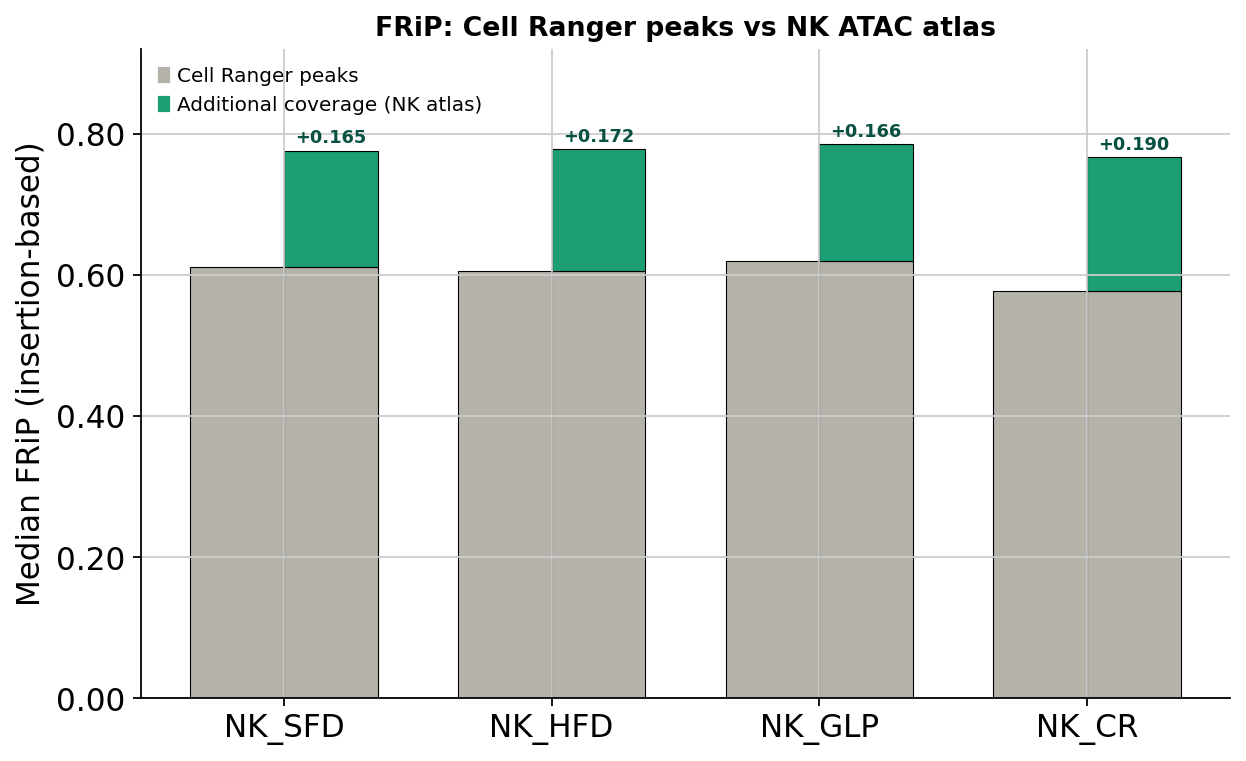

In [121]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

samples    = ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']
cr_frip    = [0.611, 0.606, 0.619, 0.577]
atlas_frip = [0.776, 0.778, 0.785, 0.767]
deltas     = [a - c for a, c in zip(atlas_frip, cr_frip)]

x     = np.arange(len(samples))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# CR bars
ax.bar(x - width/2, cr_frip, width, color='#B4B2A9', edgecolor='black', linewidth=0.5)

# Atlas bars: gray base (same as CR) + green delta stacked on top
ax.bar(x + width/2, cr_frip, width, color='#B4B2A9', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, deltas,  width, bottom=cr_frip, color='#1D9E75', edgecolor='black', linewidth=0.5)

# delta annotations
for i, (atl, delta) in enumerate(zip(atlas_frip, deltas)):
    ax.text(x[i] + width/2, atl + 0.005, f'+{delta:.3f}',
            ha='center', va='bottom', fontsize=8, color='#085041', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_ylabel('Median FRiP (insertion-based)')
ax.set_ylim(0, 0.92)
ax.set_title('FRiP: Cell Ranger peaks vs NK ATAC atlas', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.spines[['top', 'right']].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#B4B2A9', label='Cell Ranger Per-Sample Peaks'),
    mpatches.Patch(color='#1D9E75', label='NK atlas (Unified Set)'),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(final_dir + 'frip_comparison_cr_vs_atlas.png', dpi=150, bbox_inches='tight')
plt.show()


=== NK_SFD ===


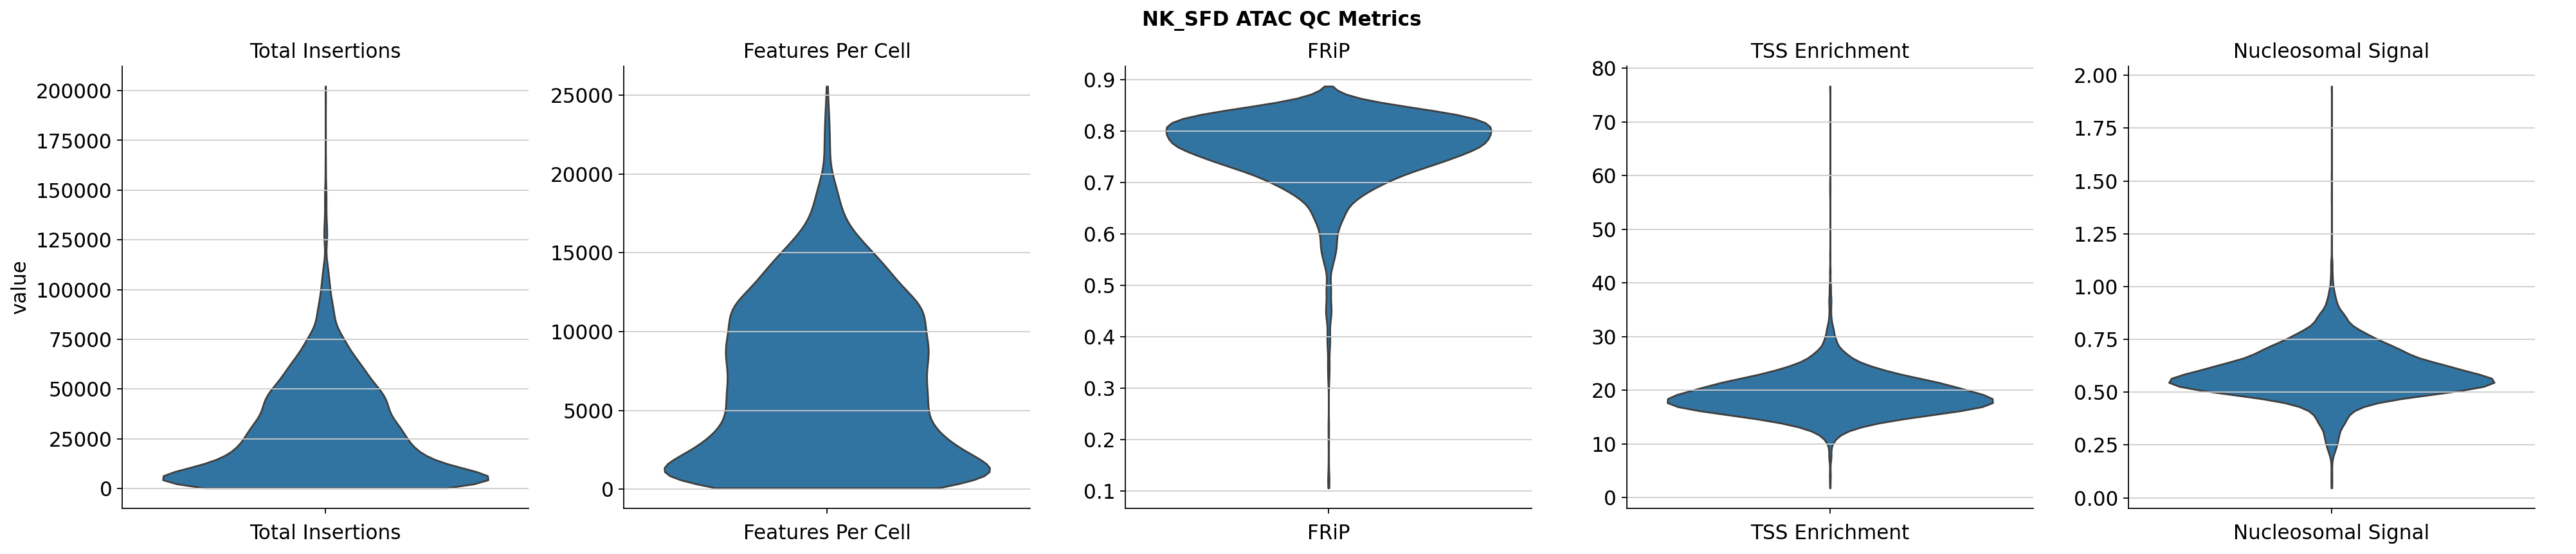


=== NK_HFD ===


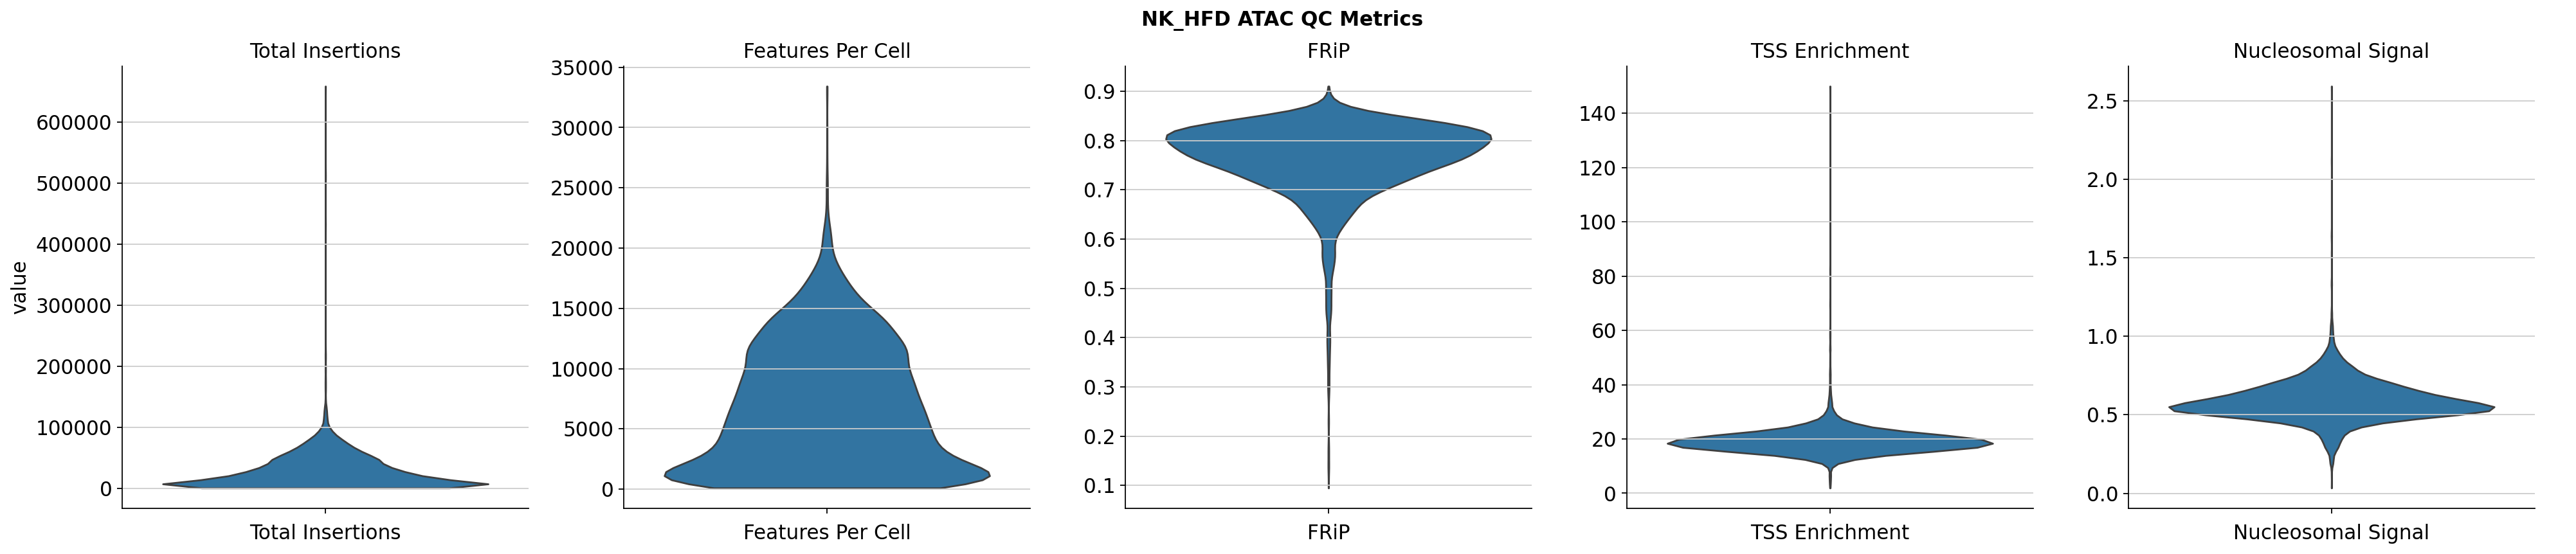


=== NK_GLP ===


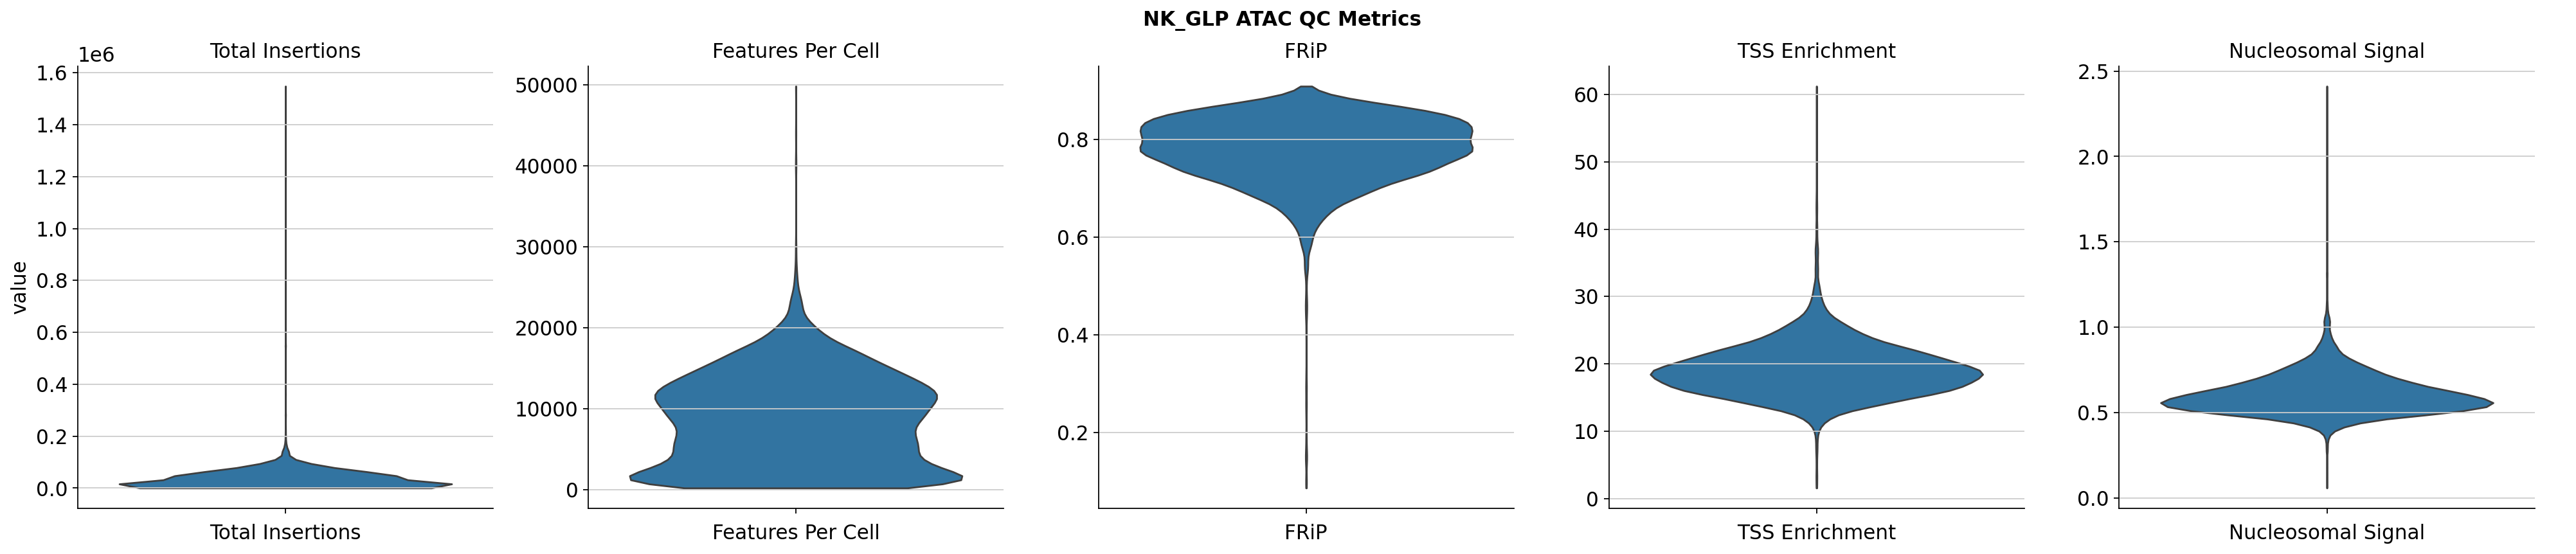


=== NK_CR ===


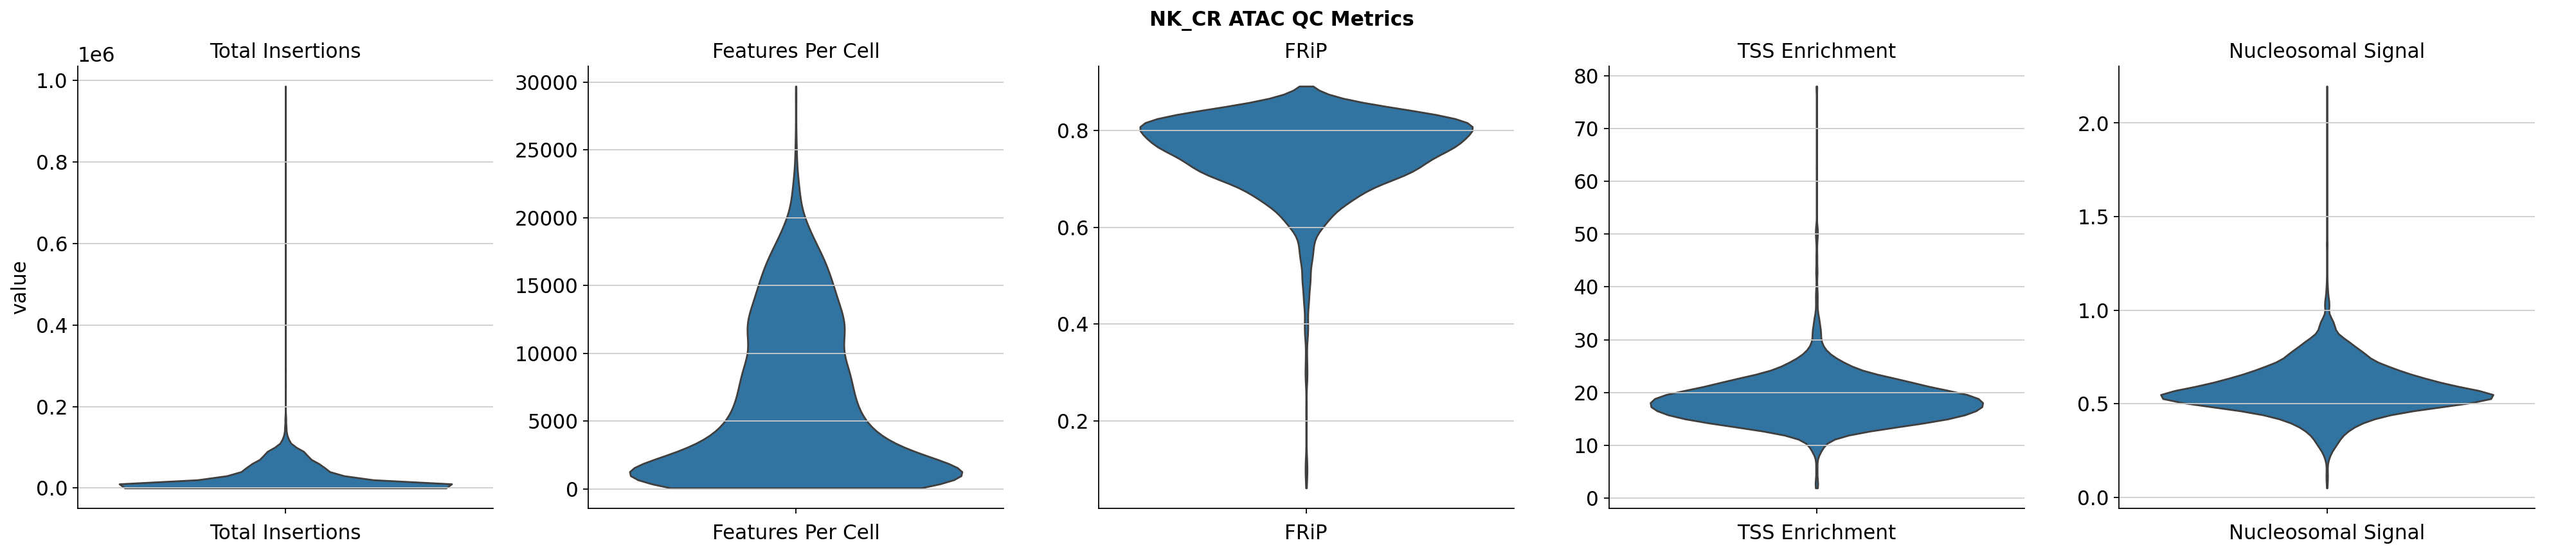

In [83]:
# Violins visualizing initial distributions #

for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    atac_qc(adata, name)


=== NK_SFD ===


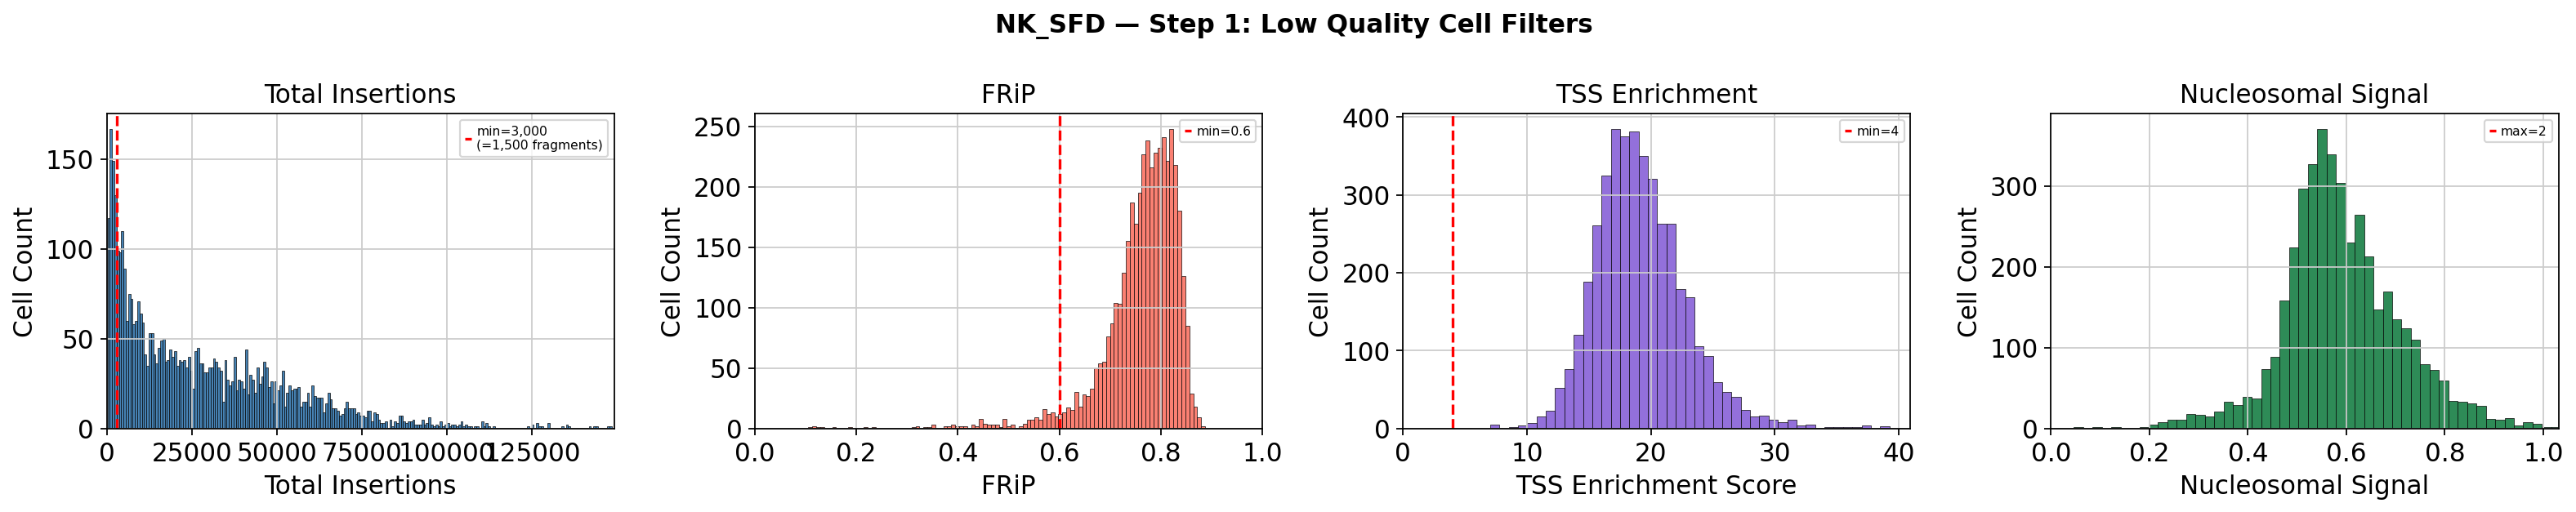

  low_insertions:   585 cells flagged
  low_frip:         160 cells flagged
  low_tsse:         3 cells flagged
  high_nucleosomal: 0 cells flagged

=== NK_HFD ===


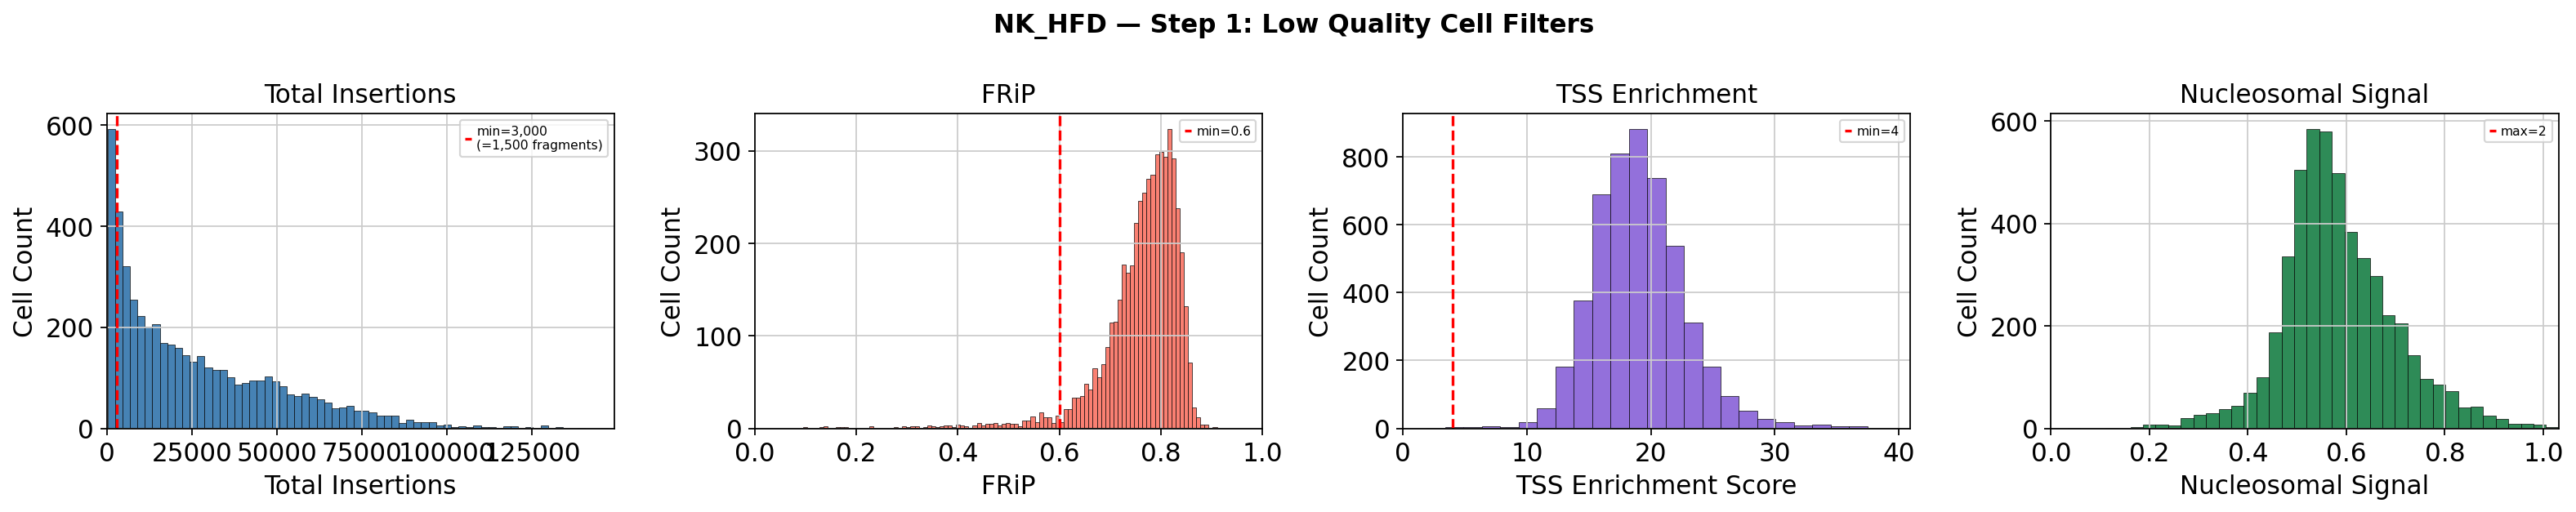

  low_insertions:   723 cells flagged
  low_frip:         191 cells flagged
  low_tsse:         3 cells flagged
  high_nucleosomal: 2 cells flagged

=== NK_GLP ===


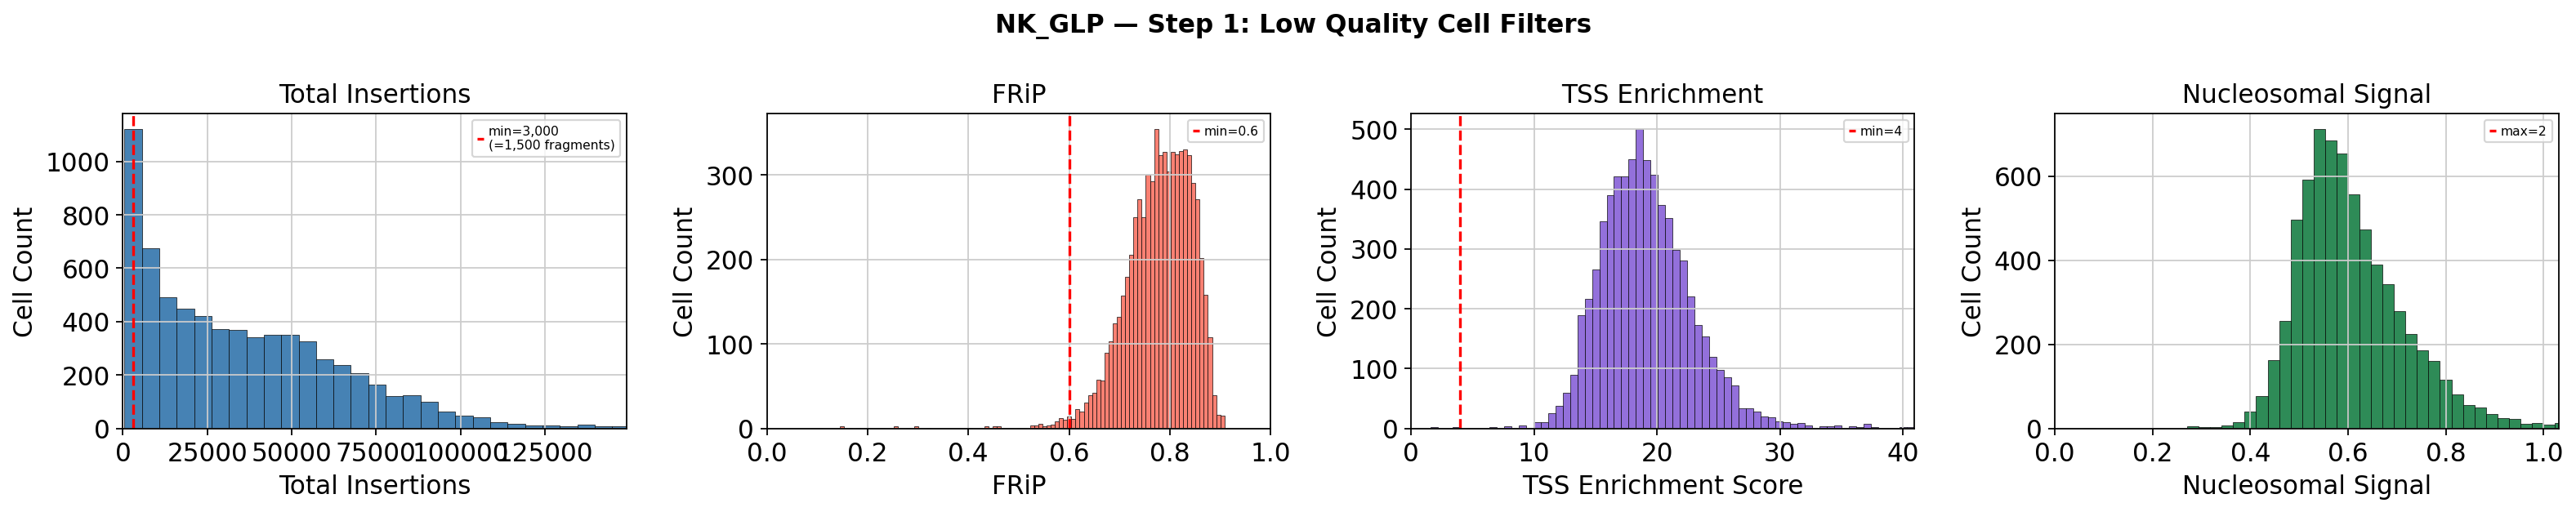

  low_insertions:   665 cells flagged
  low_frip:         84 cells flagged
  low_tsse:         6 cells flagged
  high_nucleosomal: 1 cells flagged

=== NK_CR ===


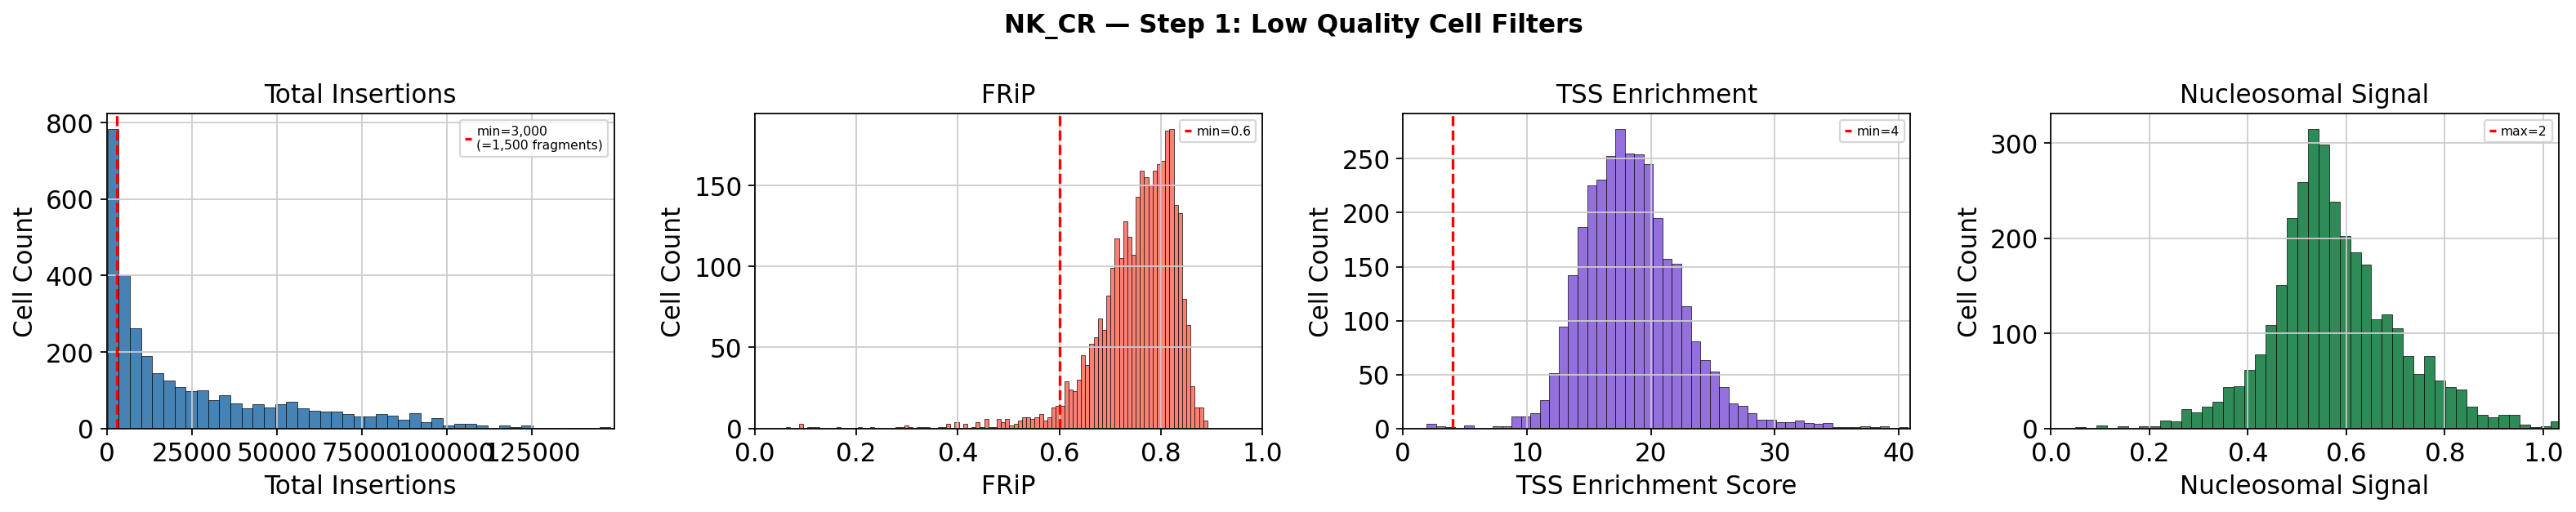

  low_insertions:   692 cells flagged
  low_frip:         142 cells flagged
  low_tsse:         7 cells flagged
  high_nucleosomal: 1 cells flagged


In [102]:
# Step 1: Low Quality Cell Filters #
atac_lowqual_thresholds = {
    'NK_SFD': dict(min_insertions=3000, min_frip=0.60, min_tsse=4, max_nucleosomal=2),
    'NK_HFD': dict(min_insertions=3000, min_frip=0.60, min_tsse=4, max_nucleosomal=2),
    'NK_GLP': dict(min_insertions=3000, min_frip=0.60, min_tsse=4, max_nucleosomal=2),
    'NK_CR':  dict(min_insertions=3000, min_frip=0.60, min_tsse=4, max_nucleosomal=2),
}

for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    atac_qc_lowqual(adata, name, **atac_lowqual_thresholds[name], global_limits=global_limits)

In [103]:
# Exclude Poor Quality:
samples_atac_filtered = {}
for name, adata in samples_atac.items():
    print(f"\n=== {name} ===")
    samples_atac_filtered[name] = atac_filter_lowqual(adata)


=== NK_SFD ===
Before low-quality filter: (4232, 180190)
  After low insertions:    (3647, 180190)
  After low FRiP:          (3590, 180190)
  After low TSS:           (3590, 180190)
  After high nucleosomal:  (3590, 180190)
Total removed: 642 (15.2%)

=== NK_HFD ===
Before low-quality filter: (5046, 180190)
  After low insertions:    (4323, 180190)
  After low FRiP:          (4239, 180190)
  After low TSS:           (4239, 180190)
  After high nucleosomal:  (4239, 180190)
Total removed: 807 (16.0%)

=== NK_GLP ===
Before low-quality filter: (6774, 180190)
  After low insertions:    (6109, 180190)
  After low FRiP:          (6029, 180190)
  After low TSS:           (6029, 180190)
  After high nucleosomal:  (6029, 180190)
Total removed: 745 (11.0%)

=== NK_CR ===
Before low-quality filter: (3277, 180190)
  After low insertions:    (2585, 180190)
  After low FRiP:          (2535, 180190)
  After low TSS:           (2535, 180190)
  After high nucleosomal:  (2535, 180190)
Total removed: 7

In [104]:
# Print means to inform 2x cutoffs #
for name, adata in samples_atac_filtered.items():
    mean_ins = adata.obs['total_insertions'].mean()
    mean_feat = adata.obs['n_features_per_cell'].mean()
    print(f"{name}:  mean_insertions={mean_ins:.0f} (2x={2*mean_ins:.0f})  mean_features={mean_feat:.0f} (2x={2*mean_feat:.0f})")

NK_SFD:  mean_insertions=31747 (2x=63495)  mean_features=7921 (2x=15842)
NK_HFD:  mean_insertions=30904 (2x=61809)  mean_features=7765 (2x=15531)
NK_GLP:  mean_insertions=38746 (2x=77492)  mean_features=9259 (2x=18517)
NK_CR:  mean_insertions=32136 (2x=64271)  mean_features=7754 (2x=15508)



=== NK_SFD ===


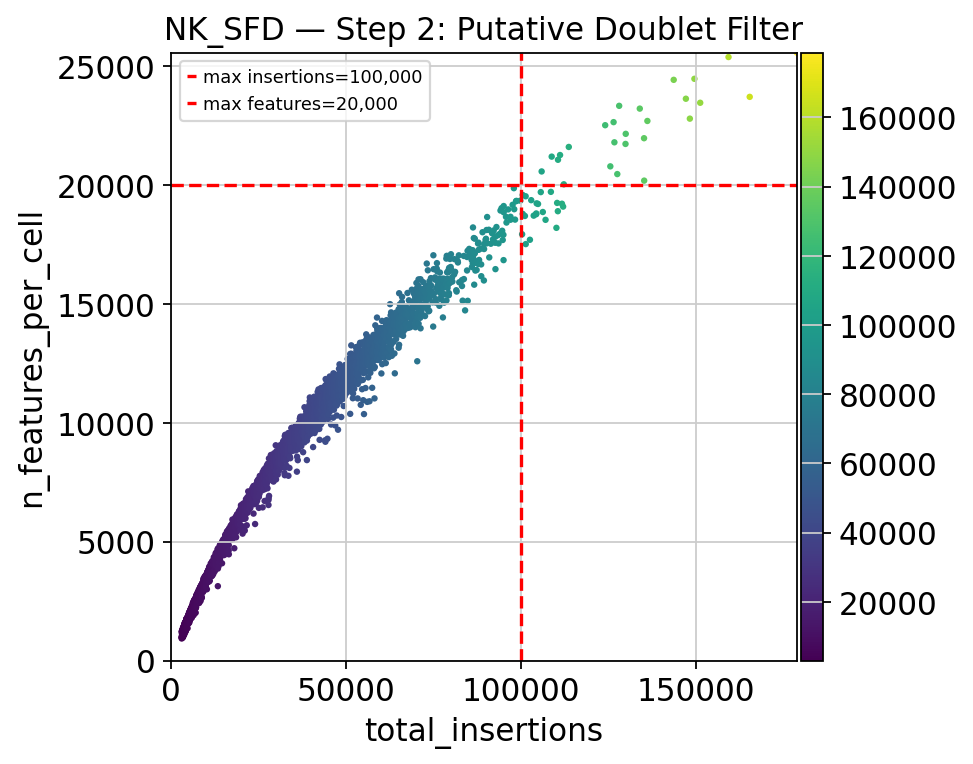

  high_insertions:       48 cells flagged
  high_features:         26 cells flagged
  total flagged (union): 48 cells

=== NK_HFD ===


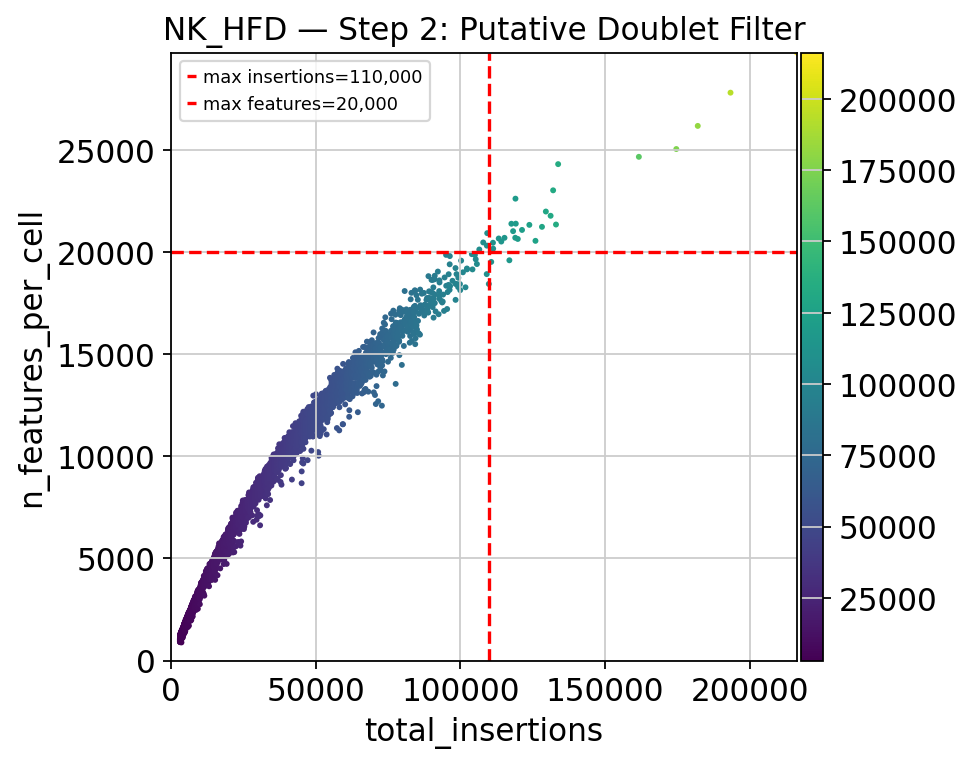

  high_insertions:       27 cells flagged
  high_features:         29 cells flagged
  total flagged (union): 31 cells

=== NK_GLP ===


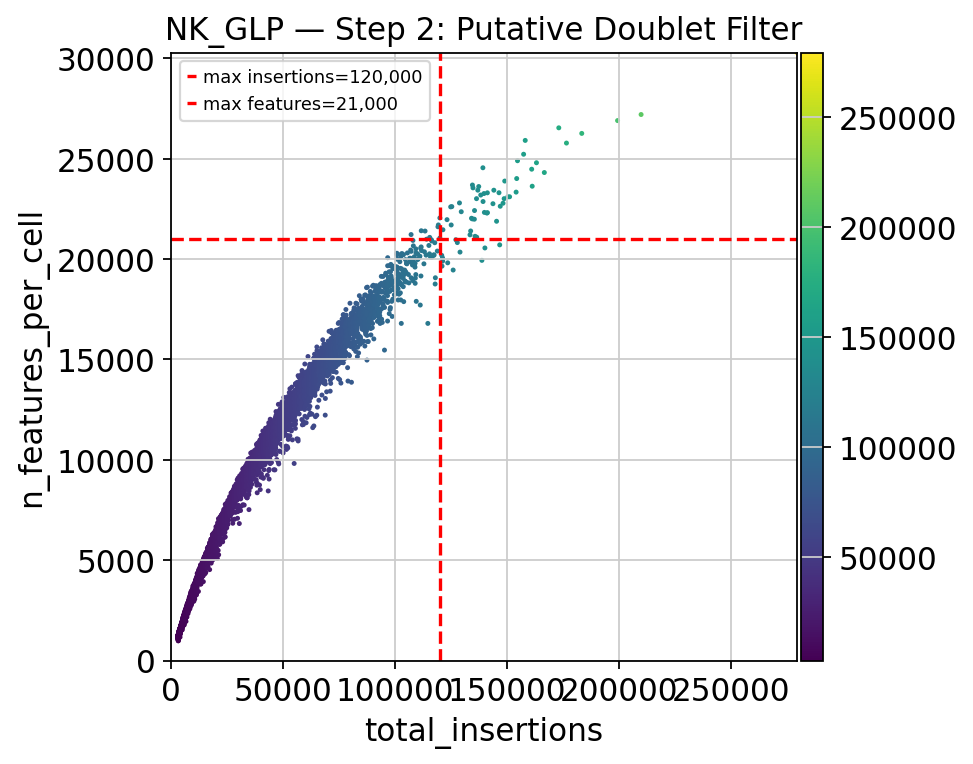

  high_insertions:       66 cells flagged
  high_features:         61 cells flagged
  total flagged (union): 73 cells

=== NK_CR ===


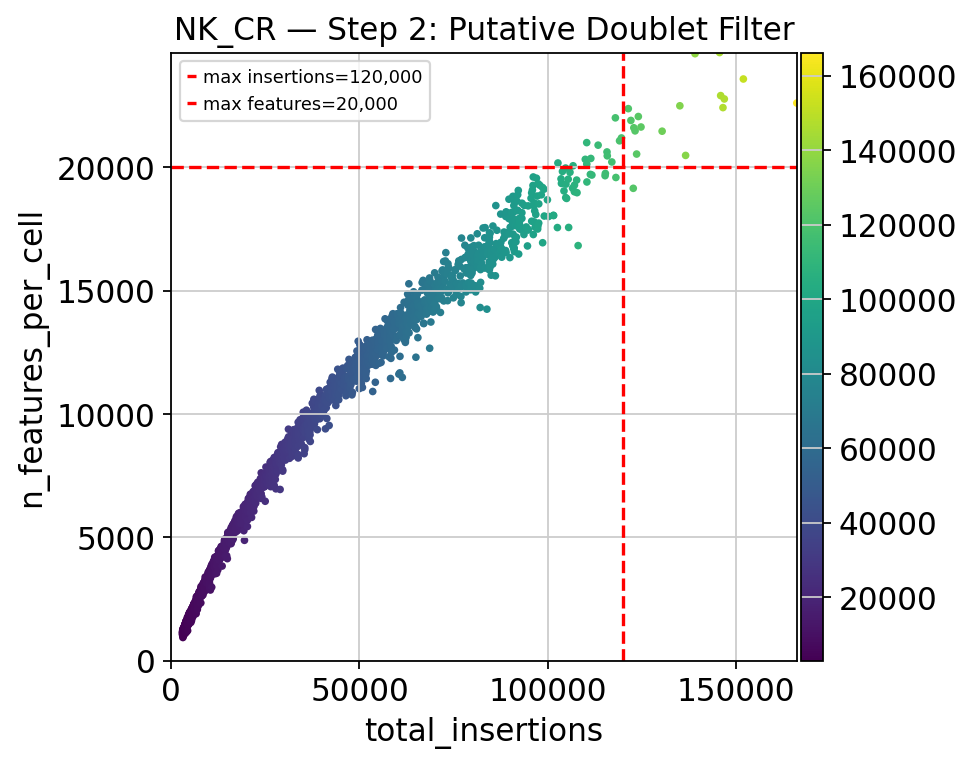

  high_insertions:       18 cells flagged
  high_features:         30 cells flagged
  total flagged (union): 31 cells


In [105]:
# Doublet Removals #

atac_doublet_thresholds = {
    'NK_SFD': dict(max_insertions=100000, max_features=20000),
    'NK_HFD': dict(max_insertions=110000, max_features=20000),
    'NK_GLP': dict(max_insertions=120000, max_features=21000),
    'NK_CR':  dict(max_insertions=120000, max_features=20000),
}

for name, adata in samples_atac_filtered.items():
    print(f"\n=== {name} ===")
    atac_qc_doublet(adata, name, **atac_doublet_thresholds[name], global_limits=global_limits)

In [106]:
# Drop these doublets #
samples_atac_clean = {}
for name, adata in samples_atac_filtered.items():
    print(f"\n=== {name} ===")
    samples_atac_clean[name] = atac_filter_doublet(adata)


=== NK_SFD ===
Before doublet filter: (3590, 180190)
  After high insertions: (3542, 180190)
  After high features:   (3542, 180190)
Total removed: 48 (1.3%)

=== NK_HFD ===
Before doublet filter: (4239, 180190)
  After high insertions: (4212, 180190)
  After high features:   (4208, 180190)
Total removed: 31 (0.7%)

=== NK_GLP ===
Before doublet filter: (6029, 180190)
  After high insertions: (5963, 180190)
  After high features:   (5956, 180190)
Total removed: 73 (1.2%)

=== NK_CR ===
Before doublet filter: (2535, 180190)
  After high insertions: (2517, 180190)
  After high features:   (2504, 180190)
Total removed: 31 (1.2%)



=== NK_SFD ===


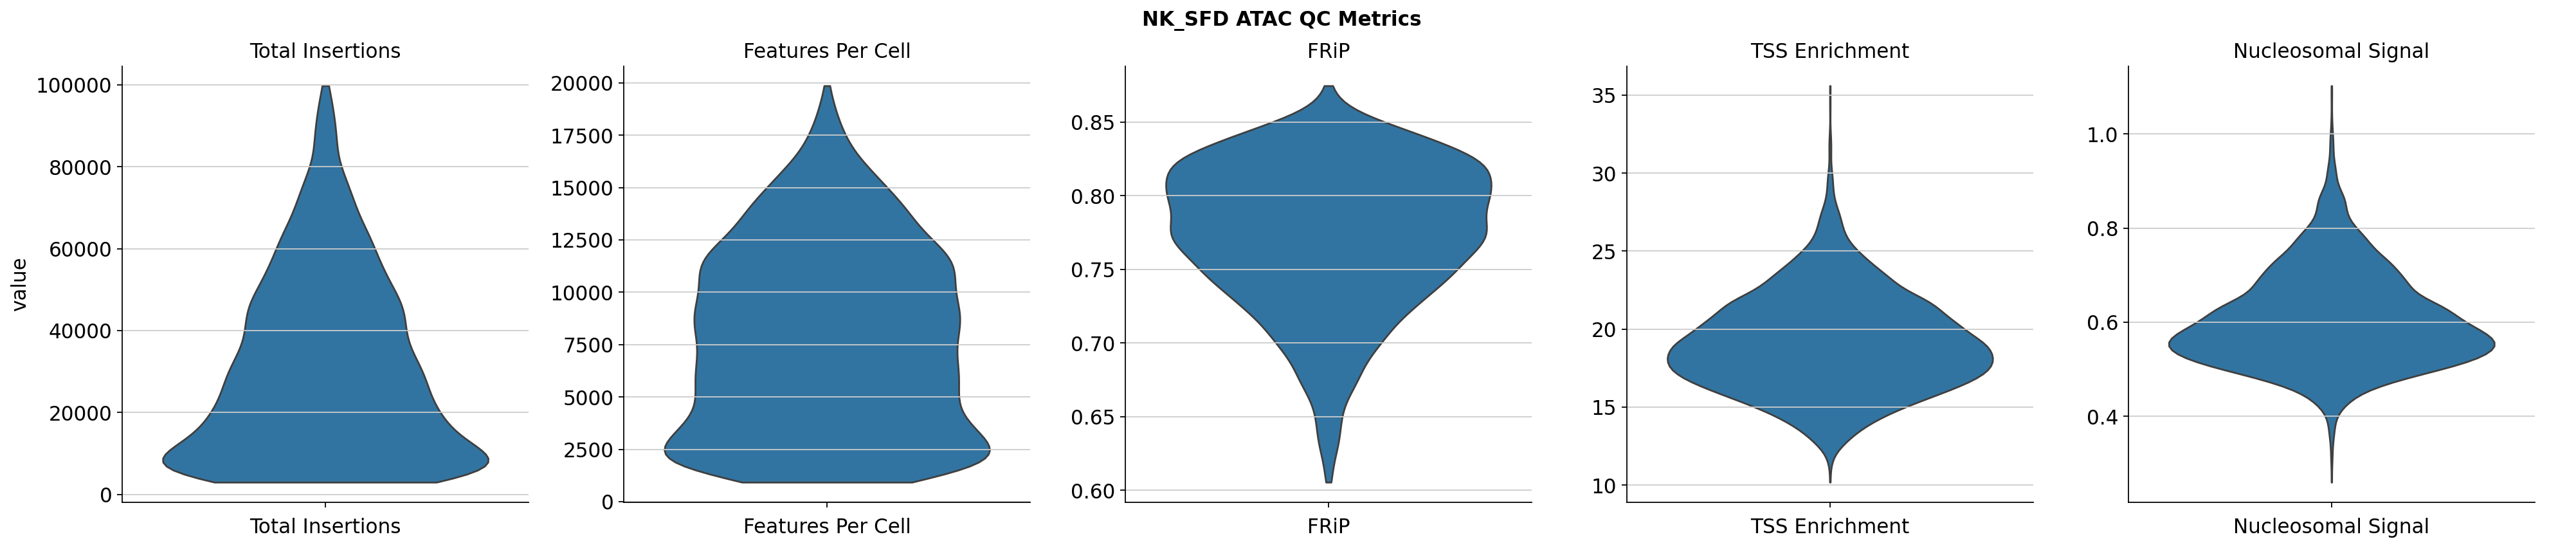


=== NK_HFD ===


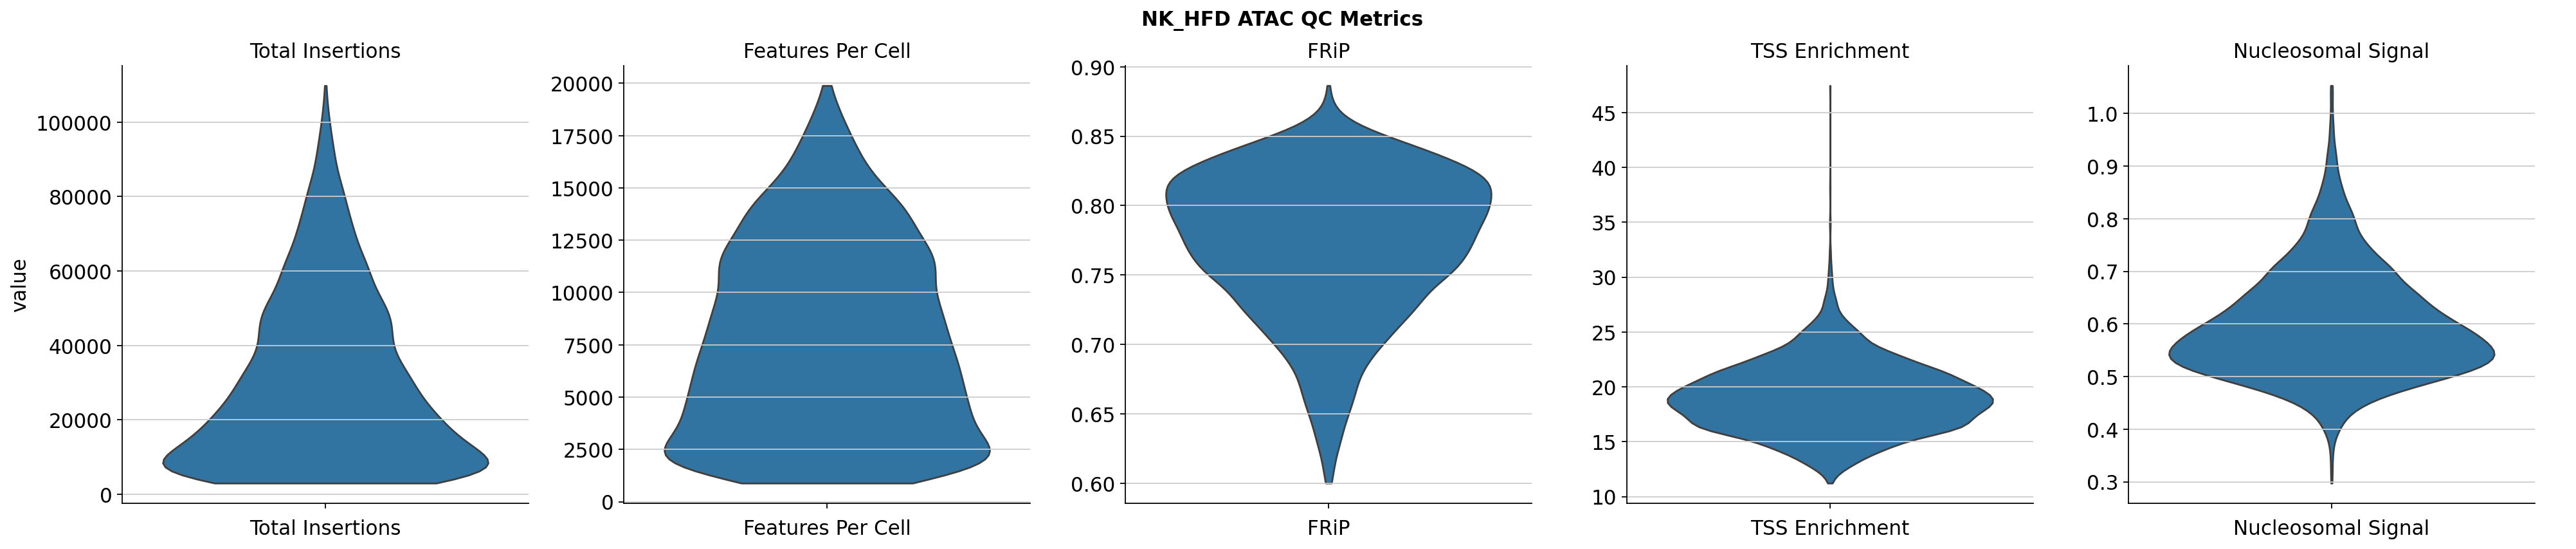


=== NK_GLP ===


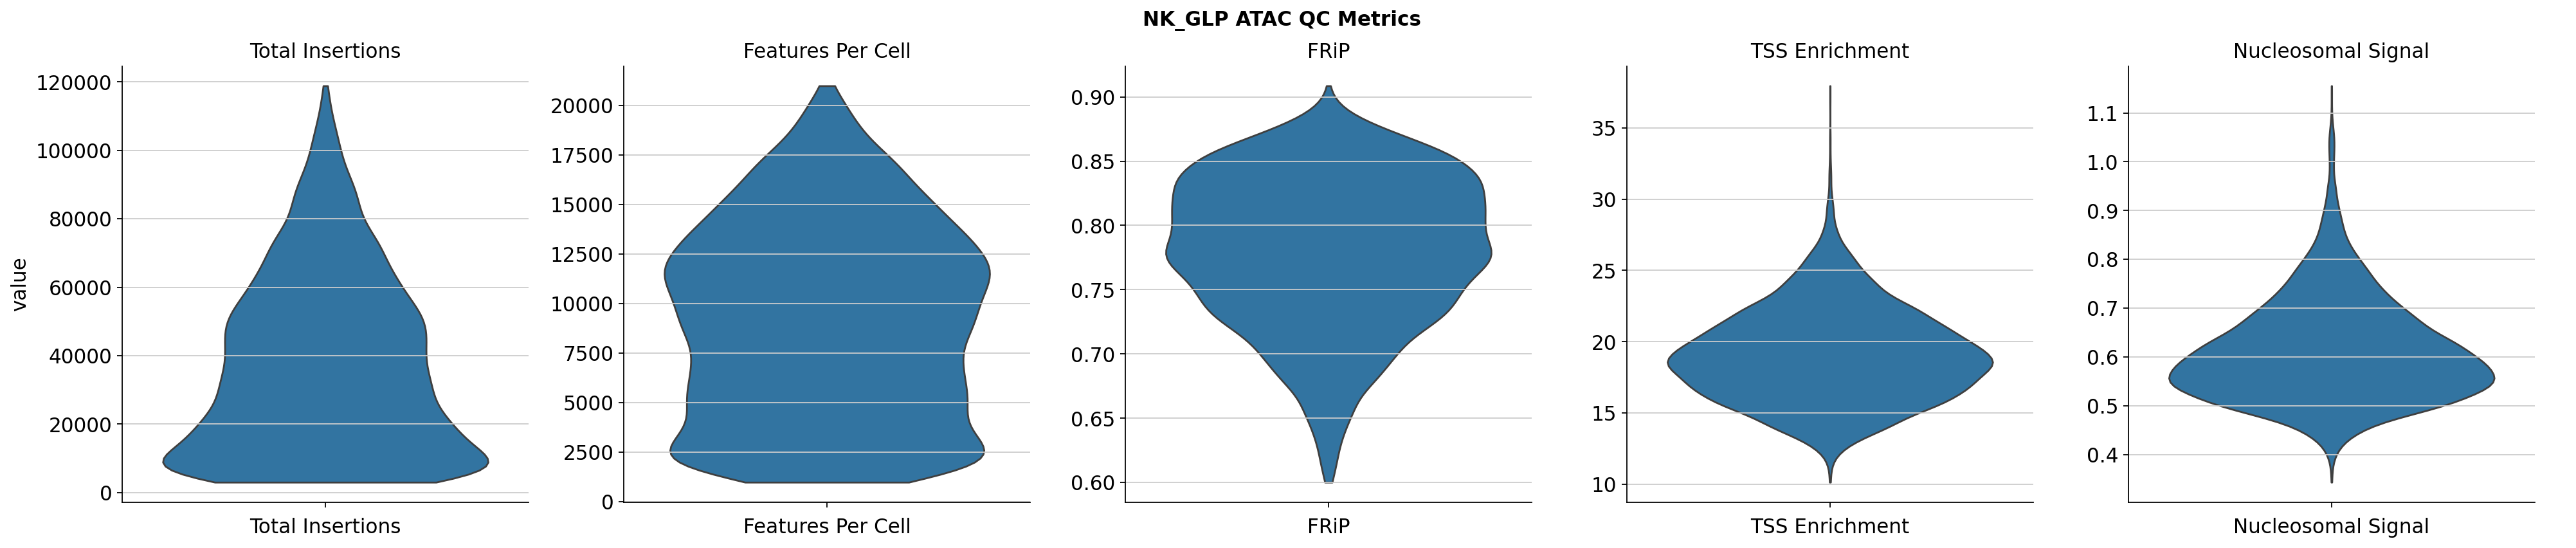


=== NK_CR ===


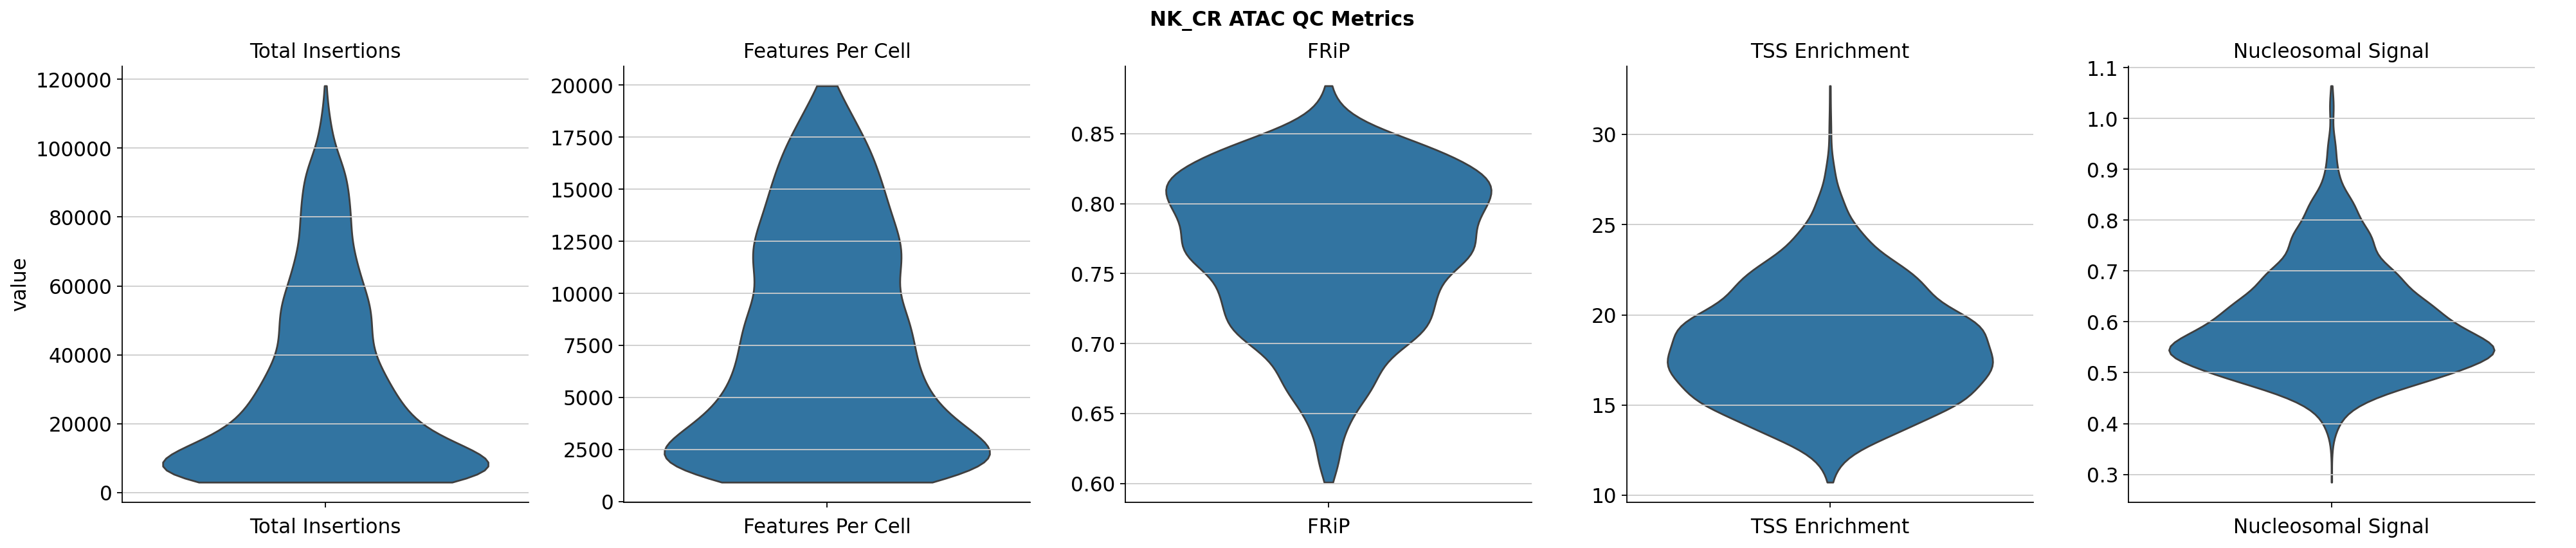

In [107]:
# visualize final distributions #
for name, adata in samples_atac_clean.items():
    print(f"\n=== {name} ===")
    atac_qc(adata, name)

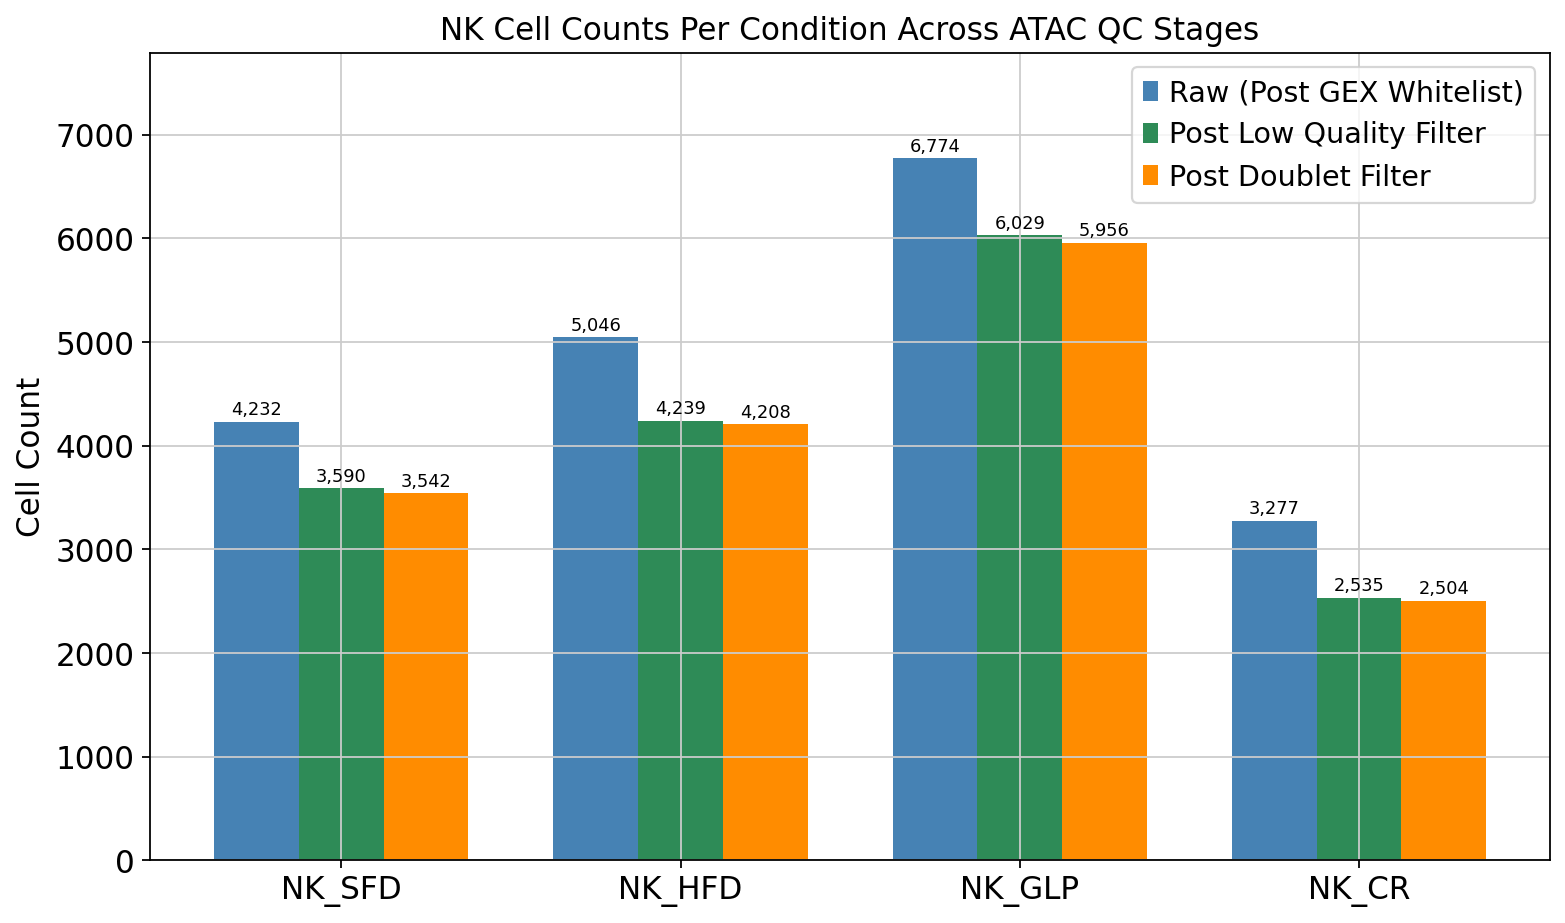

In [119]:
# ATAC Cell Counts Per QC Stage

sample_names = list(samples_atac.keys())

atac_stage_counts = {
    name: [
        samples_atac[name].n_obs,
        samples_atac_filtered[name].n_obs,
        samples_atac_clean[name].n_obs,
    ]
    for name in sample_names
}

x      = np.arange(len(sample_names))
width  = 0.25
stages = ['Raw (Post GEX Whitelist)', 'Post Low Quality Filter', 'Post Doublet Filter']
colors = ['steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (stage, color) in enumerate(zip(stages, colors)):
    vals = [atac_stage_counts[n][i] for n in sample_names]
    bars = ax.bar(x + i * width, vals, width, label=stage, color=color)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(sample_names)
ax.set_ylabel('Cell Count')
ax.set_title('NK Cell Counts Per Condition Across ATAC QC Stages')
ax.legend()
ax.set_ylim(0, max(samples_atac[n].n_obs for n in sample_names) * 1.15)
plt.tight_layout()
plt.show()

In [109]:
# Load GEX final filtered samples
gex_dir  = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/gex_filtered/'

samples_gex_final = {
    'NK_SFD': sc.read_h5ad(gex_dir + 'NK_SFD_gex_filtered.h5ad'),
    'NK_HFD': sc.read_h5ad(gex_dir + 'NK_HFD_gex_filtered.h5ad'),
    'NK_GLP': sc.read_h5ad(gex_dir + 'NK_GLP_gex_filtered.h5ad'),
    'NK_CR':  sc.read_h5ad(gex_dir + 'NK_CR_gex_filtered.h5ad'),
}

# check barcode formats
print("GEX:", list(samples_gex_final['NK_CR'].obs_names[:3]))
print("ATAC:", list(samples_atac_filtered['NK_CR'].obs_names[:3]))

GEX: ['AAACAGCCAAGTTATC-1', 'AAACAGCCAATAACCT-1', 'AAACAGCCACAAGCCT-1']
ATAC: ['NK_CR:AAACAGCCAAGTTATC-1', 'NK_CR:AAACAGCCAATAACCT-1', 'NK_CR:AAACAGCCACAAGCCT-1']


In [110]:
# Cell Counts After Each QC Stage

# raw counts from Cell Ranger ARC (cannot be derived from loaded objects)
raw_counts = {
    'NK_SFD': 4641,
    'NK_HFD': 5637,
    'NK_GLP': 8031,
    'NK_CR':  3625,
}
sample_names = list(samples_gex_final.keys())

# Build final joint barcode set
final_barcodes = {}
for name in sample_names:
    gex_barcodes  = set(samples_gex_final[name].obs_names)
    atac_barcodes = set(
        bc.split(":", 1)[1] if ":" in bc else bc
        for bc in samples_atac_clean[name].obs_names
    )
    final_barcodes[name] = gex_barcodes & atac_barcodes

# Print summary table
print("=" * 75)
print(f"{'Sample':<10} {'Raw':>8} {'Post GEX':>10} {'Post ATAC':>11} {'GEX Lost':>10} {'ATAC Lost':>11} {'Total Lost':>11}")
print("=" * 75)
for name in sample_names:
    raw        = raw_counts[name]
    post_gex   = len(samples_gex_final[name].obs_names)
    post_atac  = len(final_barcodes[name])
    gex_lost   = raw - post_gex
    atac_lost  = post_gex - post_atac
    total_lost = raw - post_atac
    print(f"{name:<10} {raw:>8,} {post_gex:>10,} {post_atac:>11,} {gex_lost:>10,} {atac_lost:>11,} {total_lost:>11,}")
print("=" * 75)
totals = {
    'raw':       sum(raw_counts.values()),
    'post_gex':  sum(len(samples_gex_final[n].obs_names) for n in sample_names),
    'post_atac': sum(len(final_barcodes[n]) for n in sample_names),
}
print(f"{'TOTAL':<10} {totals['raw']:>8,} {totals['post_gex']:>10,} {totals['post_atac']:>11,} "
      f"{totals['raw']-totals['post_gex']:>10,} {totals['post_gex']-totals['post_atac']:>11,} "
      f"{totals['raw']-totals['post_atac']:>11,}")

Sample          Raw   Post GEX   Post ATAC   GEX Lost   ATAC Lost  Total Lost
NK_SFD        4,641      4,232       3,542        409         690       1,099
NK_HFD        5,637      5,046       4,208        591         838       1,429
NK_GLP        8,031      6,774       5,956      1,257         818       2,075
NK_CR         3,625      3,277       2,504        348         773       1,121
TOTAL        21,934     19,329      16,210      2,605       3,119       5,724


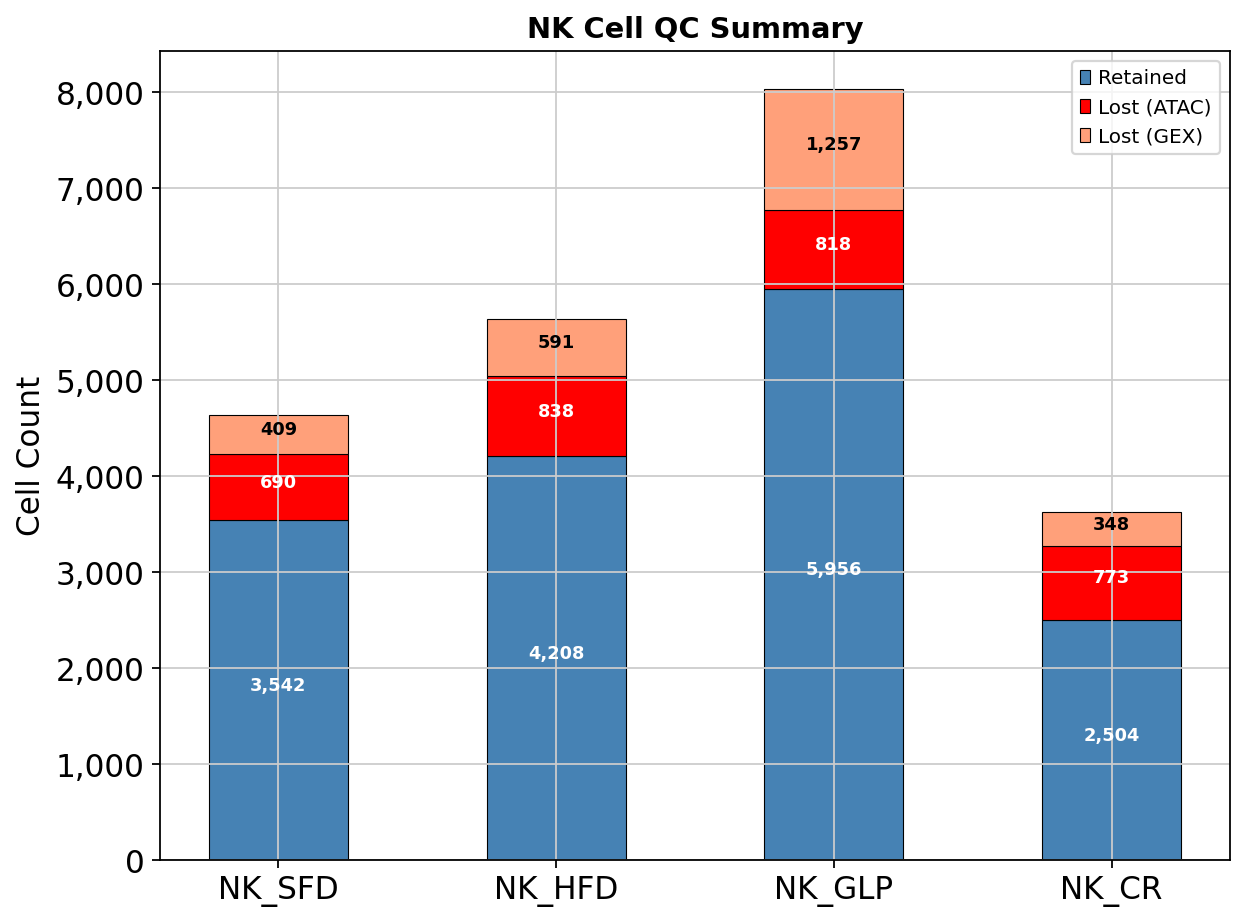

In [111]:
# Bar Plot total QC — derived from objects, only raw hardcoded
samples  = list(samples_gex_final.keys())
raw      = [raw_counts[n] for n in samples]
post_gex = [len(samples_gex_final[n].obs_names) for n in samples]
post_atac= [len(final_barcodes[n]) for n in samples]

gex_lost  = [r - g for r, g in zip(raw, post_gex)]
atac_lost = [g - a for g, a in zip(post_gex, post_atac)]

x     = np.arange(len(samples))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, post_atac, width, label='Retained',    color='steelblue',  edgecolor='black', linewidth=0.5)
ax.bar(x, atac_lost, width, bottom=post_atac,    label='Lost (ATAC)', color='red',       edgecolor='black', linewidth=0.5)
ax.bar(x, gex_lost,  width, bottom=[p+a for p,a in zip(post_atac, atac_lost)],
       label='Lost (GEX)', color='lightsalmon', edgecolor='black', linewidth=0.5)

for i, (r, g, a) in enumerate(zip(raw, post_gex, post_atac)):
    ax.text(i, a/2,         f'{a:,}',   ha='center', fontsize=8, color='white', fontweight='bold')
    ax.text(i, a + (g-a)/2, f'{g-a:,}', ha='center', fontsize=8, color='white', fontweight='bold')
    ax.text(i, g + (r-g)/2, f'{r-g:,}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_ylabel('Cell Count')
ax.set_title('NK Cell QC Summary', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
plt.tight_layout()
plt.savefig('/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/final_clean_pre_EA/qc_summary_barplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [112]:
# Subset and output clean files with good cell set:
import os

final_dir = '/Genomics/pritykinlab/seth/Diet_WL_scMultiome/Diet_GLP_scMultiome_Scripts/final_clean_pre_EA2/'

for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    joint = final_barcodes[name]

    # subset GEX
    gex  = samples_gex_final[name]
    gex_final = gex[gex.obs_names.isin(joint)].copy()

    # subset ATAC — need to match prefixed barcodes
    atac = samples_atac_filtered[name]
    atac_final = atac[[bc for bc in atac.obs_names if bc.split(":", 1)[1] in joint]].copy()

    gex_final.write_h5ad(final_dir + f'{name}_gex_final.h5ad')
    atac_final.write_h5ad(final_dir + f'{name}_atac_final.h5ad')

    print(f"{name}: GEX {gex_final.shape} | ATAC {atac_final.shape}")

NK_SFD: GEX (3542, 32285) | ATAC (3542, 180190)
NK_HFD: GEX (4208, 32285) | ATAC (4208, 180190)
NK_GLP: GEX (5956, 32285) | ATAC (5956, 180190)
NK_CR: GEX (2504, 32285) | ATAC (2504, 180190)


Retained: 122,418 / 180,190 (57,772 removed)


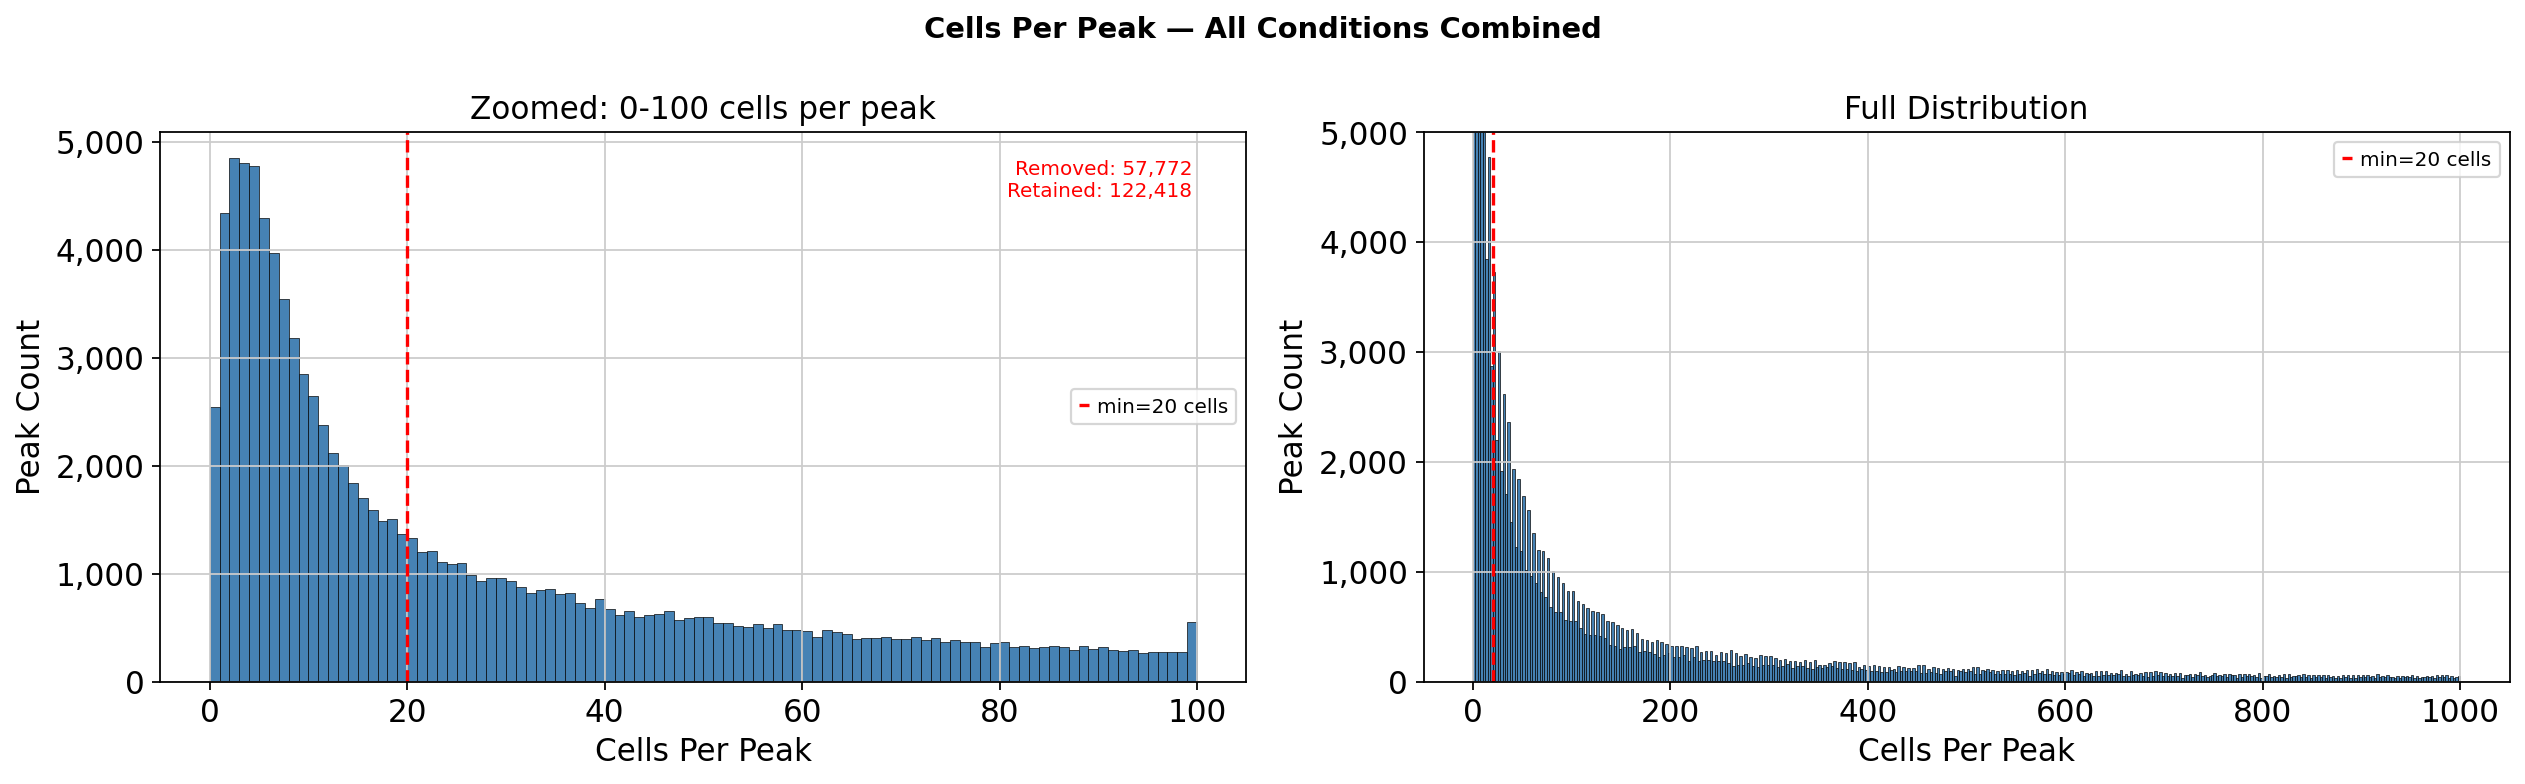

NK_SFD: 180,190 → 122,418 peaks (57,772 removed)
NK_HFD: 180,190 → 122,418 peaks (57,772 removed)
NK_GLP: 180,190 → 122,418 peaks (57,772 removed)
NK_CR: 180,190 → 122,418 peaks (57,772 removed)


In [116]:
# PEAK QC #
import anndata as ad
# Step 1: concatenate
atac_combined = ad.concat(
    [sc.read_h5ad(final_dir + f'{name}_atac_final.h5ad') for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']],
    join='outer'
)
# Step 2: compute cells per peak on combined
n_cells_per_peak_combined = np.asarray((atac_combined.X > 0).sum(axis=0)).flatten()
min_cells = 20
keep_peaks = atac_combined.var_names[n_cells_per_peak_combined >= min_cells]
n_removed  = atac_combined.n_vars - len(keep_peaks)
print(f"Retained: {len(keep_peaks):,} / {atac_combined.n_vars:,} ({n_removed:,} removed)")

# Step 3: histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cells Per Peak — All Conditions Combined', fontsize=13, fontweight='bold')

# left: zoomed 0-100 to show threshold clearly
axes[0].hist(n_cells_per_peak_combined, bins=100, range=(0, 100),
             color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].axvline(min_cells, c='r', linestyle='--', label=f'min={min_cells} cells')
axes[0].set_xlabel('Cells Per Peak')
axes[0].set_ylabel('Peak Count')
axes[0].set_title('Zoomed: 0-100 cells per peak')
axes[0].legend(fontsize=9)
axes[0].text(0.95, 0.95, f'Removed: {n_removed:,}\nRetained: {len(keep_peaks):,}',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=9, color='red')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

# right: full distribution, no range restriction
axes[1].hist(n_cells_per_peak_combined, bins=400, range=(0, 1000),
             color='steelblue', edgecolor='black', linewidth=0.3)
axes[1].set_ylim(0, 5000)
axes[1].axvline(min_cells, c='r', linestyle='--', label=f'min={min_cells} cells')
axes[1].set_xlabel('Cells Per Peak')
axes[1].set_ylabel('Peak Count')
axes[1].set_title('Full Distribution')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

plt.tight_layout()
plt.savefig(final_dir + 'peak_quality_histogram_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 4: apply unified peak mask per sample
for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    atac      = sc.read_h5ad(final_dir + f'{name}_atac_final.h5ad')
    atac_filt = atac[:, atac.var_names.isin(keep_peaks)].copy()
    atac_filt.write_h5ad(final_dir + f'{name}_atac_peak_filtered.h5ad')
    print(f"{name}: {atac.n_vars:,} → {atac_filt.n_vars:,} peaks ({atac.n_vars - atac_filt.n_vars:,} removed)")

=== Peak retention by study ===
lau2018              total=86,127  retained=72,462  removed=13,665  (84.1% retained)
pedde2024            total=90,741  retained=78,649  removed=12,092  (86.7% retained)
shih2016             total=77,464  retained=70,048  removed= 7,416  (90.4% retained)
wiedemann2021        total=59,600  retained=49,021  removed=10,579  (82.2% retained)
wiedemann2021b       total=87,251  retained=79,459  removed= 7,792  (91.1% retained)
yoshida2019          total=69,009  retained=59,975  removed= 9,034  (86.9% retained)


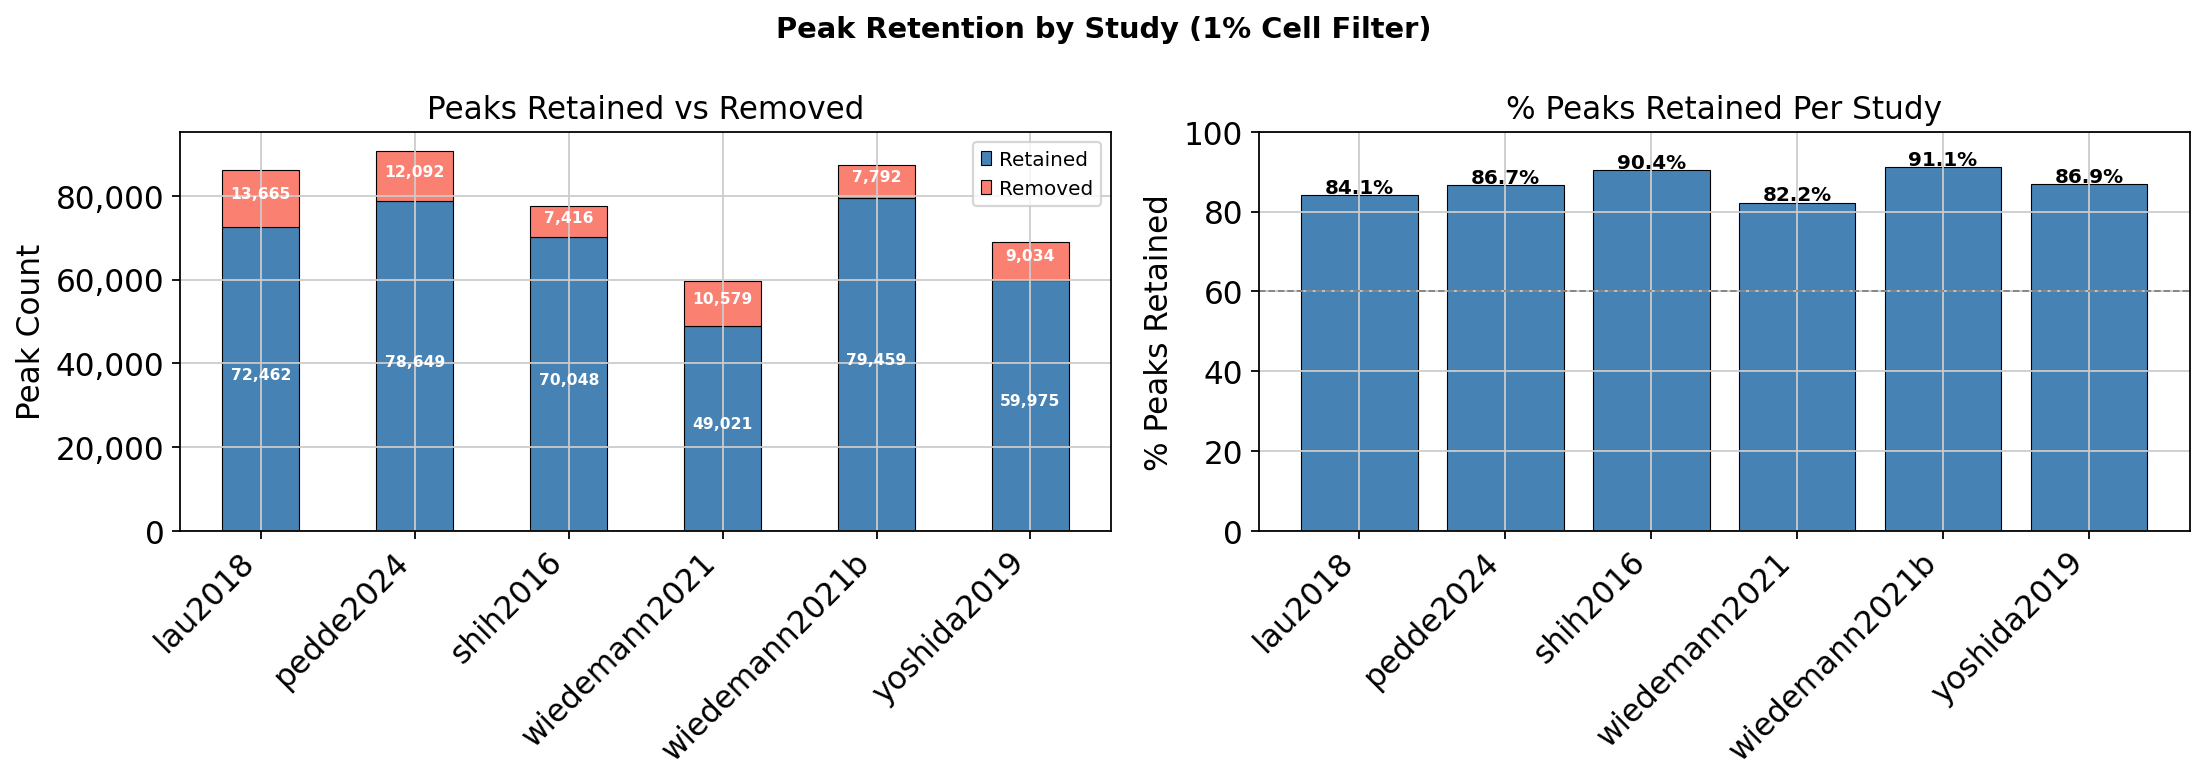

In [117]:
# load atlas metadata
atlas_meta = pd.read_csv('/Genomics/pritykinlab/seth/ATACCompendium/archived_atlas_outputs/all_atac_peaks.tsv', sep='\t')
atlas_meta.index = atlas_meta['name']

studies = ['lau2018', 'pedde2024', 'shih2016', 'wiedemann2021', 'wiedemann2021b', 'yoshida2019']

# compute retention stats
records = []
print("=== Peak retention by study ===")
for study in studies:
    study_peaks    = atlas_meta[atlas_meta[study] == True]['name']
    study_retained = [p for p in study_peaks if p in keep_peaks]
    study_removed  = len(study_peaks) - len(study_retained)
    pct_retained   = 100 * len(study_retained) / max(len(study_peaks), 1)
    print(f"{study:<20} total={len(study_peaks):>6,}  retained={len(study_retained):>6,}  "
          f"removed={study_removed:>6,}  ({pct_retained:.1f}% retained)")
    records.append({
        'study':    study,
        'total':    len(study_peaks),
        'retained': len(study_retained),
        'removed':  study_removed,
        'pct':      pct_retained,
    })

df = pd.DataFrame(records)

# bar plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Peak Retention by Study (1% Cell Filter)', fontsize=13, fontweight='bold')

x     = np.arange(len(studies))
width = 0.5

# left: stacked bar retained vs removed
axes[0].bar(x, df['retained'], width, label='Retained', color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].bar(x, df['removed'],  width, bottom=df['retained'], label='Removed', color='salmon', edgecolor='black', linewidth=0.5)

for i, row in df.iterrows():
    axes[0].text(i, row['retained']/2,
                 f'{row["retained"]:,}', ha='center', fontsize=7, color='white', fontweight='bold')
    axes[0].text(i, row['retained'] + row['removed']/2,
                 f'{row["removed"]:,}', ha='center', fontsize=7, color='white', fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(studies, rotation=45, ha='right')
axes[0].set_ylabel('Peak Count')
axes[0].set_title('Peaks Retained vs Removed')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))

# right: % retained
bars = axes[1].bar(df['study'], df['pct'], color='steelblue', edgecolor='black', linewidth=0.5)
for bar, p in zip(bars, df['pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{p:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].set_xticklabels(studies, rotation=45, ha='right')
axes[1].set_ylabel('% Peaks Retained')
axes[1].set_ylim(0, 100)
axes[1].set_title('% Peaks Retained Per Study')
axes[1].axhline(60, c='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(final_dir + 'peak_retention_by_study.png', dpi=150, bbox_inches='tight')
plt.show()

        Cells  Genes   Peaks
Sample                      
NK_SFD   3542  32285  122418
NK_HFD   4208  32285  122418
NK_GLP   5956  32285  122418
NK_CR    2504  32285  122418


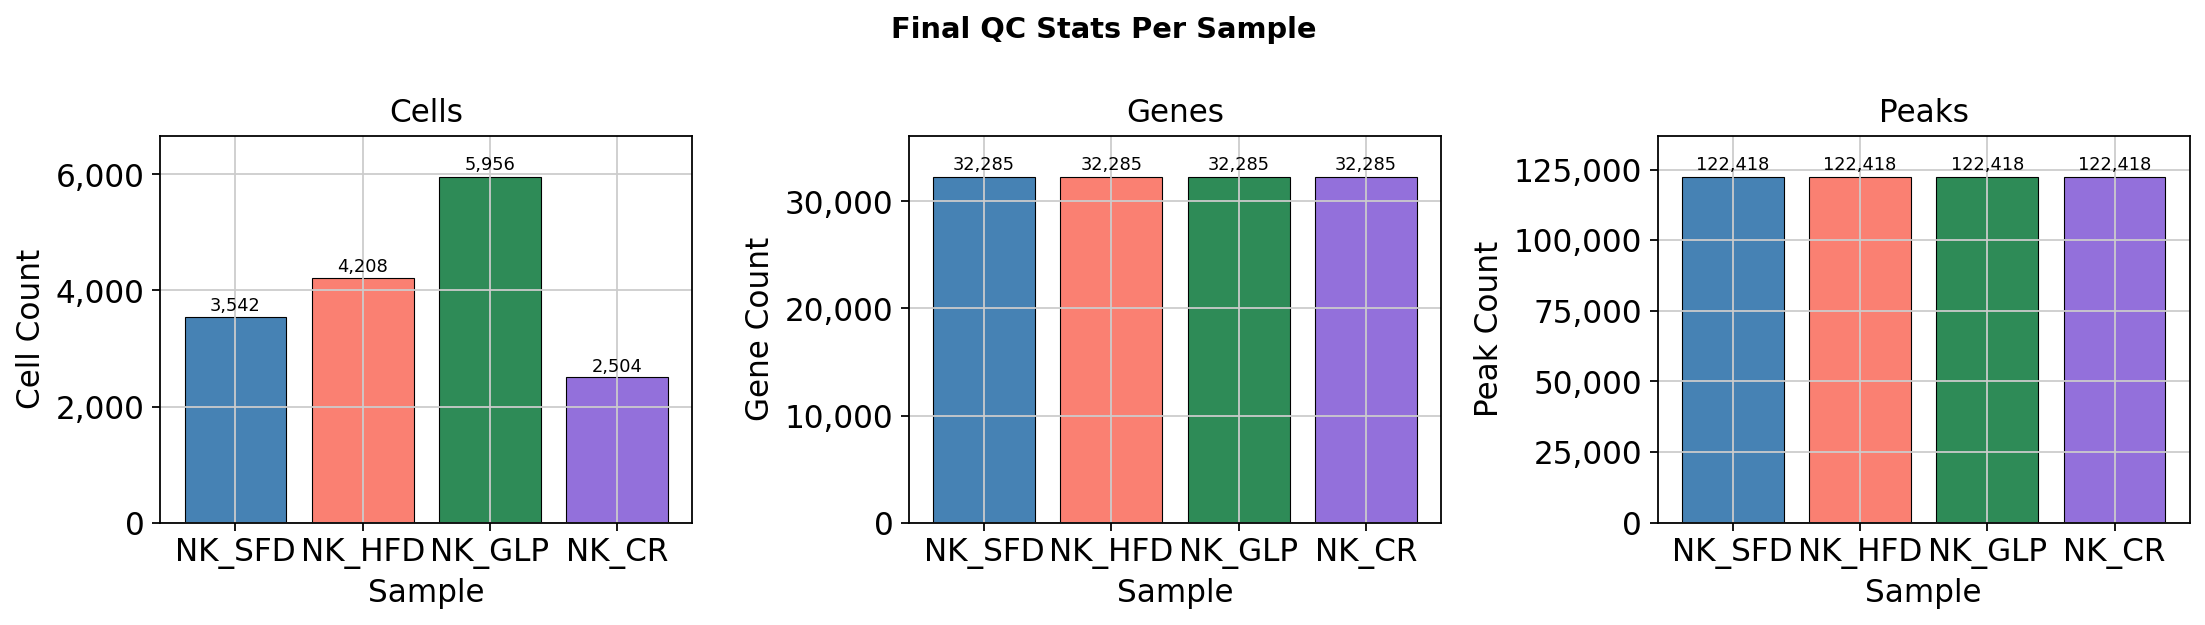

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# collect stats
rows = []
for name in ['NK_SFD', 'NK_HFD', 'NK_GLP', 'NK_CR']:
    gex  = sc.read_h5ad(final_dir + f'{name}_gex_final.h5ad')
    atac = sc.read_h5ad(final_dir + f'{name}_atac_peak_filtered.h5ad')
    rows.append({
        'Sample':  name,
        'Cells':   gex.n_obs,
        'Genes':   gex.n_vars,
        'Peaks':   atac.n_vars,
    })

df = pd.DataFrame(rows).set_index('Sample')
print(df.to_string())

# bar plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Final QC Stats Per Sample', fontsize=13, fontweight='bold')

colors = ['steelblue', 'salmon', 'seagreen', 'mediumpurple']
metrics = ['Cells', 'Genes', 'Peaks']
ylabels = ['Cell Count', 'Gene Count', 'Peak Count']

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    ax.set_ylim(0, df[metric].max() * 1.12)
    ax.bar(df.index, df[metric], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Sample')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    for i, (idx, val) in enumerate(df[metric].items()):
        ax.text(i, val + val * 0.01, f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(final_dir + 'final_qc_stats.png', dpi=150, bbox_inches='tight')
plt.show()